In [601]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import time

import warnings
warnings.filterwarnings('ignore')

In [602]:
df = pd.read_csv('heart_cleaned.csv')

In [603]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289.0,0,172,0,0.0,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,160,180.0,0,156,0,1.0,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,130,283.0,0,98,0,0.0,False,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,138,214.0,0,108,1,1.5,True,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,150,195.0,0,122,0,0.0,False,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [604]:
class FeatureCategorizer:
    def __init__(self, df):
        self.df = df.copy()
        self.continuous_features = []
        self.binary_features = []
        
    def categorize_features(self):
        """Automatically categorize features as continuous or binary"""
        print("Analyzing features...")
        print("="*50)
        
        for col in self.df.columns:
            unique_vals = self.df[col].nunique()
            is_numeric = pd.api.types.is_numeric_dtype(self.df[col])
            unique_values = sorted(self.df[col].unique())
            
            print(f"\n{col}:")
            print(f"  - Unique values: {unique_vals}")
            print(f"  - Is numeric: {is_numeric}")
            print(f"  - Sample values: {unique_values[:5] if len(unique_values) > 5 else unique_values}")
            
            if is_numeric:
                if unique_vals == 2 or set(self.df[col].unique()).issubset({0, 1, 0.0, 1.0}):
                    self.binary_features.append(col)
                    print(f"  → Classified as: BINARY")
                else:
                    self.continuous_features.append(col)
                    print(f"  → Classified as: CONTINUOUS")
            else:
                # Handle boolean or string binary features
                if unique_vals == 2:
                    self.binary_features.append(col)
                    print(f"  → Classified as: BINARY")
                else:
                    print(f"  → Classified as: OTHER (will be ignored)")
        
        print(f"\n{'='*50}")
        print("FINAL CATEGORIZATION:")
        print(f"{'='*50}")
        print(f"Continuous features ({len(self.continuous_features)}): {self.continuous_features}")
        print(f"Binary features ({len(self.binary_features)}): {self.binary_features}")
        
        return self.continuous_features, self.binary_features
    
    def get_feature_stats(self):
        """Get detailed statistics for each feature type"""
        print(f"\n{'='*50}")
        print("FEATURE STATISTICS:")
        print(f"{'='*50}")
        
        if self.continuous_features:
            print("\nCONTINUOUS FEATURES:")
            for feature in self.continuous_features:
                data = self.df[feature]
                print(f"\n{feature}:")
                print(f"  Mean: {data.mean():.2f}")
                print(f"  Std:  {data.std():.2f}")
                print(f"  Min:  {data.min():.2f}")
                print(f"  Max:  {data.max():.2f}")
                print(f"  Q1:   {data.quantile(0.25):.2f}")
                print(f"  Q3:   {data.quantile(0.75):.2f}")
        
        if self.binary_features:
            print("\nBINARY FEATURES:")
            for feature in self.binary_features:
                value_counts = self.df[feature].value_counts()
                print(f"\n{feature}:")
                for val, count in value_counts.items():
                    percentage = (count / len(self.df)) * 100
                    print(f"  {val}: {count} ({percentage:.1f}%)")

In [605]:
# Categorize features
categorizer = FeatureCategorizer(df)
continuous_features, binary_features = categorizer.categorize_features()

# Get detailed statistics
categorizer.get_feature_stats()

Analyzing features...

Age:
  - Unique values: 50
  - Is numeric: True
  - Sample values: [np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]
  → Classified as: CONTINUOUS

Sex:
  - Unique values: 2
  - Is numeric: True
  - Sample values: [np.int64(0), np.int64(1)]
  → Classified as: BINARY

RestingBP:
  - Unique values: 67
  - Is numeric: True
  - Sample values: [np.int64(0), np.int64(80), np.int64(92), np.int64(94), np.int64(95)]
  → Classified as: CONTINUOUS

Cholesterol:
  - Unique values: 222
  - Is numeric: True
  - Sample values: [np.float64(85.0), np.float64(100.0), np.float64(110.0), np.float64(113.0), np.float64(117.0)]
  → Classified as: CONTINUOUS

FastingBS:
  - Unique values: 2
  - Is numeric: True
  - Sample values: [np.int64(0), np.int64(1)]
  → Classified as: BINARY

MaxHR:
  - Unique values: 119
  - Is numeric: True
  - Sample values: [np.int64(60), np.int64(63), np.int64(67), np.int64(69), np.int64(70)]
  → Classified as: CONTINUOUS

ExerciseAngina

In [606]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop('HeartDisease', axis=1)
Y = df['HeartDisease']

mutua_informazione_feature = []

def analyze_feature_information(X, Y, continuous_features, binary_features):
    """
    Calcola la mutua informazione media per feature numeriche e binarie.
    
    Args:
        X (pd.DataFrame): dataset delle feature
        y (pd.Series o array): target
        numerical_features (list): lista nomi delle feature numeriche
        binary_features (list): lista nomi delle feature binarie
    
    Returns:
        dict: valori medi di mutua informazione
    """
    # Calcolo mutua informazione per tutte le feature
    mi = mutual_info_classif(X, Y, discrete_features='auto', random_state=42)
    mi_df = pd.DataFrame({
        "feature": X.columns,
        "mutual_info": mi
    })
    
    # Separazione numeriche e binarie
    mi_numerical = mi_df[mi_df["feature"].isin(continuous_features)]["mutual_info"].mean()
    mi_binary = mi_df[mi_df["feature"].isin(binary_features)]["mutual_info"].mean()
    
    return {
        "MI_numerical": mi_numerical,
        "MI_binary": mi_binary
    }

ris = analyze_feature_information(X, Y, continuous_features, binary_features)
print(ris)

{'MI_numerical': np.float64(0.06646737346489448), 'MI_binary': np.float64(0.06725815612608918)}


In [607]:
class ProgressiveOutlierGenerator:
    def __init__(self, df, continuous_features, pre_fitted_scaler=None, pre_fitted_pca=None):
        self.original_df = df.copy()
        self.current_df = df.copy()
        self.continuous_features = continuous_features
        self.contamination_history = []
        self.contaminated_values = set()
        
        # Calcola il numero totale di valori numerici
        self.total_numeric_values = len(df) * len(continuous_features)
        
        print(f"Initialized with:")
        print(f"  - Dataset size: {len(df)} samples")
        print(f"  - Continuous features: {len(continuous_features)}")
        print(f"  - Total numeric values: {self.total_numeric_values}")
        print(f"  - Mode: Individual value contamination")

    def add_continuous_outliers(self, contamination_rate=0.02, methods=['extreme'], seed=None):
        """Contamina singoli valori numerici"""
        rng = np.random.default_rng(seed)
        if not self.continuous_features:
            return {}

        univariate_methods = [m for m in methods if m != 'multivariate']
        if not univariate_methods:
            univariate_methods = ['extreme']

        # Calcola quanti nuovi valori contaminare
        n_new_outliers = int(round(self.total_numeric_values * contamination_rate))
        
        if n_new_outliers == 0 and contamination_rate > 0:
            n_new_outliers = 1

        # Genera tutte le possibili combinazioni (row_label, feature)
        all_value_positions = []
        for row_label in self.current_df.index:
            for feature in self.continuous_features:
                all_value_positions.append((row_label, feature))

        # Filtra quelle già contaminate
        available_positions = [pos for pos in all_value_positions 
                             if pos not in self.contaminated_values]

        if len(available_positions) == 0:
            print("No more clean values available for contamination.")
            return {}

        if len(available_positions) < n_new_outliers:
            n_new_outliers = len(available_positions)
            print(f"Warning: Only {len(available_positions)} clean values remaining. Using all of them.")

        # Scegli casualmente le posizioni da contaminare
        chosen_positions = rng.choice(len(available_positions), size=n_new_outliers, replace=False)
        chosen_positions = [available_positions[i] for i in chosen_positions]

        contamination_info = {}

        # Assicurati di poter ripristinare i valori originali
        if not hasattr(self, 'original_values'):
            self.original_values = {}

        for row_label, feature in chosen_positions:
            method = str(rng.choice(univariate_methods))

            # Salva il valore originale
            if row_label not in self.original_values:
                self.original_values[row_label] = {}
            if feature not in self.original_values[row_label]:
                self.original_values[row_label][feature] = self.current_df.at[row_label, feature]

            # Dati puliti: escludi valori già contaminati per questa feature
            clean_positions = [(rl, f) for rl, f in all_value_positions 
                             if f == feature and (rl, f) not in self.contaminated_values]
            clean_data = pd.Series([self.current_df.at[rl, f] for rl, f in clean_positions]).dropna()
            
            if clean_data.empty:
                continue

            q1, q3 = clean_data.quantile(0.25), clean_data.quantile(0.75)
            iqr = q3 - q1
            std_val = float(clean_data.std()) if clean_data.std() != 0 else 1.0
            min_val, max_val = clean_data.min(), clean_data.max()

            orig_val = float(self.current_df.at[row_label, feature])

            # Genera l'outlier
            if method == 'extreme':
                if rng.random() < 0.5:
                    outlier_val = q1 - rng.uniform(3, 6) * iqr
                    outlier_val = max(outlier_val, float(min_val) - 3 * std_val)
                else:
                    outlier_val = q3 + rng.uniform(3, 6) * iqr
                    outlier_val = min(outlier_val, float(max_val) + 3 * std_val)
            elif method == 'shift':
                shift_factor = rng.choice([-1, 1]) * rng.uniform(2, 4)
                outlier_val = orig_val + shift_factor * std_val
            elif method == 'noise':
                noise_factor = rng.choice([-1, 1]) * rng.uniform(3, 5)
                outlier_val = orig_val + noise_factor * std_val
            else:
                # fallback
                outlier_val = q3 + rng.uniform(3, 6) * iqr

            # Domain-aware clipping
            if feature in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']:
                lower_bound = 0
                outlier_val = max(outlier_val, lower_bound)

            # Preserva il tipo intero se necessario
            if pd.api.types.is_integer_dtype(self.current_df[feature].dtype):
                outlier_val = int(round(outlier_val))

            # Applica la modifica
            self.current_df.at[row_label, feature] = outlier_val

            # Registra l'informazione
            contamination_info.setdefault(feature, []).append({
                'index': row_label,
                'original_value': self.original_values[row_label][feature],
                'outlier_value': outlier_val,
                'method': method
            })

        # Aggiorna il set dei valori contaminati
        self.contaminated_values.update(set(chosen_positions))

        return contamination_info

    def progressive_contamination(self, steps=10, max_contamination=1, continuous_methods=['extreme', 'shift']):
        """Progressively contaminate individual numeric values in steps."""
        # Filtra i metodi univariati
        univariate_methods = [m for m in continuous_methods if m != 'multivariate']
        if not univariate_methods:
            print("No valid univariate methods provided. Using default methods.")
            univariate_methods = ['extreme', 'shift']
        
        contamination_rates = np.linspace(0, max_contamination, steps + 1)[1:]
        datasets = [self.original_df.copy()]
        
        print("Starting progressive contamination (individual values)...")
        print(f"Steps: {steps}")
        print(f"Methods: {univariate_methods}")
        print(f"Target contamination rates: {[f'{rate:.3f}' for rate in contamination_rates]}")
        print(f"Total numeric values to contaminate: {self.total_numeric_values}")
        
        for step, target_rate in enumerate(contamination_rates, 1):
            print(f"\n--- Step {step}/{steps}: Target contamination {target_rate:.3f} ---")
            
            current_contamination_rate = len(self.contaminated_values) / self.total_numeric_values
            incremental_rate = target_rate - current_contamination_rate
            
            if incremental_rate <= 0:
                print("Target contamination already reached or exceeded.")
                datasets.append(self.current_df.copy())
                continue
            
            print(f"Adding individual value outliers (incremental rate: {incremental_rate:.3f})...")
            cont_info = self.add_continuous_outliers(
                contamination_rate=incremental_rate,
                methods=univariate_methods
            )
            
            actual_contamination = len(self.contaminated_values) / self.total_numeric_values
            print(f"Actual total contamination: {actual_contamination:.3f}")
            print(f"Total contaminated values: {len(self.contaminated_values)}/{self.total_numeric_values}")
            
            self.contamination_history.append({
                'step': step,
                'target_rate': target_rate,
                'actual_rate': actual_contamination,
                'contaminated_values': len(self.contaminated_values),
                'continuous_info': cont_info,
            })
            
            datasets.append(self.current_df.copy())

            
            res = analyze_feature_information(self.current_df, Y, continuous_features, binary_features)
            res["perc_outliers"] = step / steps
            mutua_informazione_feature.append(res)
        
        return datasets, self.contamination_history

    def get_contamination_summary(self):
        """Print a detailed summary of contamination."""
        print(f"\n{'='*60}")
        print("CONTAMINATION SUMMARY (INDIVIDUAL VALUES)")
        print(f"{'='*60}")
        
        print(f"Original dataset size: {len(self.original_df)} samples")
        print(f"Continuous features: {len(self.continuous_features)}")
        print(f"Total numeric values: {self.total_numeric_values}")
        print(f"Total contaminated values: {len(self.contaminated_values)}")
        print(f"Overall contamination rate: {len(self.contaminated_values)/self.total_numeric_values:.3f}")
        
        # Conta contamination per feature
        feature_counts = {}
        for row_label, feature in self.contaminated_values:
            feature_counts[feature] = feature_counts.get(feature, 0) + 1
        
        print(f"\nContamination by feature:")
        for feature in self.continuous_features:
            count = feature_counts.get(feature, 0)
            total_feature_values = len(self.original_df)
            rate = count / total_feature_values if total_feature_values > 0 else 0
            print(f"  {feature}: {count}/{total_feature_values} values ({rate:.3f})")
        
        # Dettagli per step
        for i, history in enumerate(self.contamination_history, 1):
            print(f"\nStep {i}:")
            print(f"  Target rate: {history['target_rate']:.3f}")
            print(f"  Actual rate: {history['actual_rate']:.3f}")
            print(f"  Contaminated values: {history['contaminated_values']}")
            
            if history['continuous_info']:
                print("  New outliers by feature:")
                for feature, outliers in history['continuous_info'].items():
                    if outliers:
                        method_counts = {}
                        for outlier in outliers:
                            method = outlier['method']
                            method_counts[method] = method_counts.get(method, 0) + 1
                        
                        method_str = ", ".join([f"{method}: {count}" for method, count in method_counts.items()])
                        print(f"    {feature}: {len(outliers)} new outliers ({method_str})")

    def reset_to_clean(self):
        """Reset to original clean dataset."""
        self.current_df = self.original_df.copy()
        self.contaminated_values = set()
        self.contamination_history = []
        print("Dataset reset to original clean state.")
    
    def get_datasets(self):
        """Return both clean and current contaminated dataset."""
        return self.original_df.copy(), self.current_df.copy()
    
    def debug_outlier_counts(self):
        """Debug function to check outlier counts per feature and method"""
        print("\n" + "="*60)
        print("OUTLIER DEBUG INFORMATION (INDIVIDUAL VALUES)")
        print("="*60)
        
        print(f"Total contaminated values: {len(self.contaminated_values)}")
        print(f"Total numeric values: {self.total_numeric_values}")
        print(f"Overall contamination rate: {len(self.contaminated_values)/self.total_numeric_values:.3f}")
        
        feature_method_counts = {}
        for feature in self.continuous_features:
            feature_method_counts[feature] = {}
        
        for history in self.contamination_history:
            for feature, outliers in history['continuous_info'].items():
                for outlier_info in outliers:
                    method = outlier_info['method']
                    if method not in feature_method_counts[feature]:
                        feature_method_counts[feature][method] = 0
                    feature_method_counts[feature][method] += 1
        
        for feature in self.continuous_features:
            print(f"\n{feature}:")
            if feature_method_counts[feature]:
                total_feature_outliers = sum(feature_method_counts[feature].values())
                for method, count in feature_method_counts[feature].items():
                    print(f"  - {method} outliers: {count}")
                print(f"  - Total outliers: {total_feature_outliers}/{len(self.original_df)}")
                print(f"  - Feature contamination rate: {total_feature_outliers/len(self.original_df):.3f}")
            else:
                print(f"  - No outliers")

In [608]:
loaded_scaler = joblib.load('scaler.joblib')
loaded_pca = joblib.load('pca.joblib')

# Initialize the outlier generator with categorized features
generator = ProgressiveOutlierGenerator(df, continuous_features, pre_fitted_scaler=loaded_scaler, 
    pre_fitted_pca=loaded_pca)

# Generate progressive outliers
datasets, contamination_history = generator.progressive_contamination(
    steps=10,                          
    max_contamination=1,           
    continuous_methods=['extreme', 'shift', 'noise']  
)

# Print detailed summary
generator.get_contamination_summary()

Initialized with:
  - Dataset size: 918 samples
  - Continuous features: 5
  - Total numeric values: 4590
  - Mode: Individual value contamination
Starting progressive contamination (individual values)...
Steps: 10
Methods: ['extreme', 'shift', 'noise']
Target contamination rates: ['0.100', '0.200', '0.300', '0.400', '0.500', '0.600', '0.700', '0.800', '0.900', '1.000']
Total numeric values to contaminate: 4590

--- Step 1/10: Target contamination 0.100 ---
Adding individual value outliers (incremental rate: 0.100)...
Actual total contamination: 0.100
Total contaminated values: 459/4590

--- Step 2/10: Target contamination 0.200 ---
Adding individual value outliers (incremental rate: 0.100)...
Actual total contamination: 0.200
Total contaminated values: 918/4590

--- Step 3/10: Target contamination 0.300 ---
Adding individual value outliers (incremental rate: 0.100)...
Actual total contamination: 0.300
Total contaminated values: 1377/4590

--- Step 4/10: Target contamination 0.400 ---


Generating visualizations at specific contamination steps...
Total contamination steps: 10
Steps to visualize: [2, 5, 9]


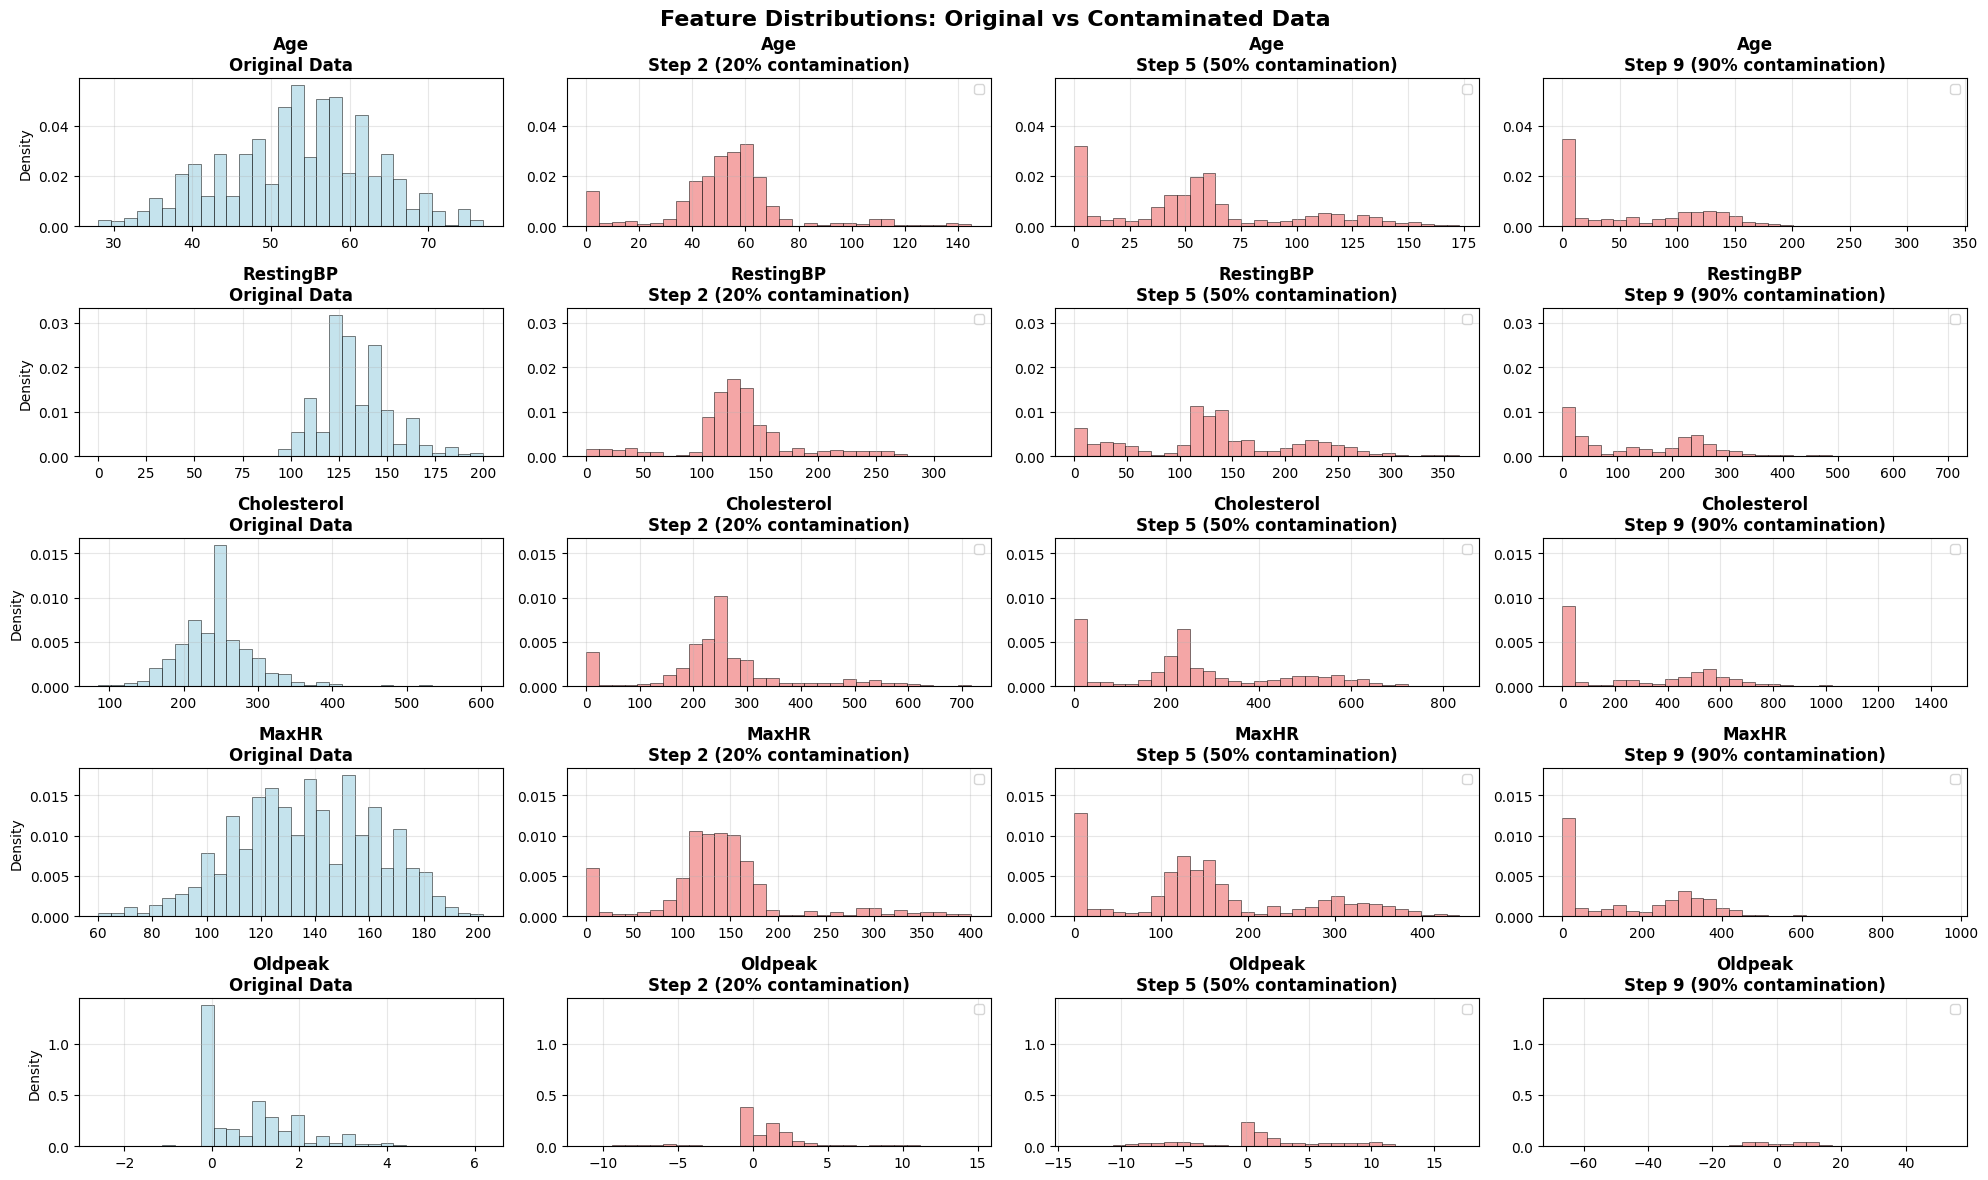

In [609]:
def plot_feature_distributions_at_steps(generator, datasets, steps_to_show=[2, 5], figsize=(20, 12)):
    """
    Plot distributions showing original data vs contaminated data at specific contamination steps.
    
    Parameters:
    -----------
    generator : ProgressiveOutlierGenerator
        Il generatore di outliers
    datasets : list
        Lista dei dataset per ogni step
    steps_to_show : list
        Lista degli step da visualizzare (es. [2, 5, 9] per 20%, 50% e 90% se hai 10 step totali)
    figsize : tuple
        Dimensione della figura
    """
    n_features = len(generator.continuous_features)
    if n_features == 0:
        print("No features to visualize")
        return
    
    # Calcola la percentuale di contaminazione per ogni step
    total_steps = len(datasets) - 1  # -1 perché il primo dataset è quello originale
    if total_steps == 0:
        print("No contamination steps available")
        return
    
    print(f"Total contamination steps: {total_steps}")
    print(f"Steps to visualize: {steps_to_show}")
    
    # Verifica che gli step richiesti esistano
    valid_steps = [step for step in steps_to_show if step < len(datasets)]
    if not valid_steps:
        print(f"Error: Requested steps {steps_to_show} are out of range. Available steps: 0-{len(datasets)-1}")
        return
    
    # Calcola il layout della griglia
    n_datasets = len(valid_steps) + 1  # +1 per il dataset originale
    n_cols = n_datasets  # Una colonna per ogni dataset
    n_rows = n_features
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle single feature case
    if n_features == 1:
        axes = axes.reshape(1, -1)
    elif n_datasets == 1:
        axes = axes.reshape(-1, 1)
    
    # Colori per ogni dataset
    colors = ['lightblue', 'lightcoral', 'lightcoral', 'lightcoral', 'lightcoral']
    
    for i, feature in enumerate(generator.continuous_features):
        # Colonna 0: Dataset originale
        ax_orig = axes[i, 0] if n_features > 1 or n_datasets > 1 else axes
        original_data = generator.original_df[feature]
        
        ax_orig.hist(original_data, alpha=0.7, bins=30, color='lightblue', 
                    density=True, edgecolor='black', linewidth=0.5)
        ax_orig.set_title(f'{feature}\nOriginal Data', fontsize=12, fontweight='bold')
        ax_orig.set_ylabel('Density')
        ax_orig.grid(True, alpha=0.3)
        
        # Colonne successive: Dataset contaminati agli step specificati
        for col_idx, step in enumerate(valid_steps):
            ax = axes[i, col_idx + 1] if n_features > 1 or n_datasets > 1 else axes
            
            # Dati contaminati per questo step
            contaminated_data = datasets[step][feature]
            
            # Percentuale di contaminazione per questo step
            contamination_rate = (step / total_steps) * 100 if total_steps > 0 else 0
            
            # Plot istogramma
            ax.hist(contaminated_data, alpha=0.7, bins=30, 
                   color=colors[col_idx + 1], density=True, 
                   edgecolor='black', linewidth=0.5)
            
            # Trova gli outliers per questo step e questa feature
            outliers_for_step = []
            
            # Raccoglie tutti gli outliers fino a questo step
            for hist_idx in range(min(step + 1, len(generator.contamination_history))):
                history = generator.contamination_history[hist_idx]
                if feature in history['continuous_info']:
                    for outlier_info in history['continuous_info'][feature]:
                        outliers_for_step.append(outlier_info['outlier_value'])
                
            ax.set_title(f'{feature}\nStep {step} ({contamination_rate:.0f}% contamination)', 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if outliers_for_step:
                ax.legend(fontsize=9)
        
        # Imposta la stessa scala Y per tutti i grafici di questa feature
        y_limits = []
        for col_idx in range(n_datasets):
            ax = axes[i, col_idx] if n_features > 1 or n_datasets > 1 else axes
            y_limits.extend(ax.get_ylim())
        
        y_min, y_max = min(y_limits), max(y_limits)
        for col_idx in range(n_datasets):
            ax = axes[i, col_idx] if n_features > 1 or n_datasets > 1 else axes
            ax.set_ylim(y_min, y_max)

    plt.suptitle(f'Feature Distributions: Original vs Contaminated Data',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Usage examples:
print("Generating visualizations at specific contamination steps...")

# Mostra le distribuzioni al 20% e 50% e 90%
plot_feature_distributions_at_steps(generator, datasets, steps_to_show=[2, 5, 9])

In [610]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import time
from sklearn.inspection import permutation_importance


In [611]:
all_metrics_outliers = []

def calculate_metrics(y_test, y_pred, model_name, approach, step_idx):
    """
    Calculate metrics and return a dictionary with model info
    """
    metrics = {
        'model': model_name,
        'approach': approach,
        'step': step_idx,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    }
    
    # Print metrics (to maintain your current output format)
    print(f"Misure di performance globali {model_name.lower()} {approach.lower()}\n")
    print('Accuracy:', metrics['accuracy'])
    print('Precision:', metrics['precision'])
    print('Recall:', metrics['recall'])
    print('F1-score:', metrics['f1_score'])
    
    return metrics

timing_collector_outliers = {
    'dt_naive_training': 0,
    'dt_optimal_training': 0, 
    'dt_hyperparameter': 0,
    'svm_naive_training': 0,
    'svm_optimal_training': 0,
    'svm_hyperparameter': 0,
    'nn_naive_training': 0,
    'nn_optimal_training': 0,
    'nn_hyperparameter': 0
}



DECISION TREE - NAIVE


===== Training Decision Tree (Naive) at Step 0 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Step 0 | Training time (Naive): 0.0067 sec
Step 0 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.7771739130434783
Precision: 0.8080808080808081
Recall: 0.7843137254901961
F1-score: 0.7960199004975125


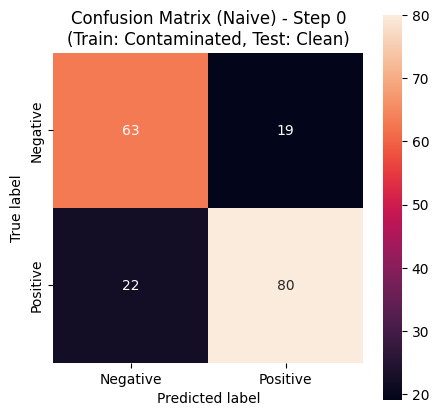


===== Training Decision Tree (Naive) at Step 1 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 1 | Training time (Naive): 0.0025 sec
Step 1 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.782608695652174
Precision: 0.81
Recall: 0.7941176470588235
F1-score: 0.801980198019802


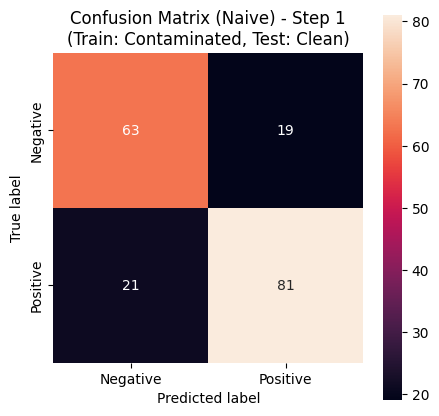


===== Training Decision Tree (Naive) at Step 2 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 2 | Training time (Naive): 0.0033 sec
Step 2 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.7880434782608695
Precision: 0.8461538461538461
Recall: 0.7549019607843137
F1-score: 0.7979274611398963


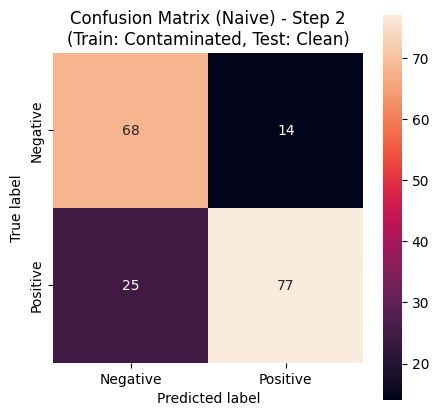


===== Training Decision Tree (Naive) at Step 3 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 3 | Training time (Naive): 0.0039 sec
Step 3 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.7880434782608695
Precision: 0.8387096774193549
Recall: 0.7647058823529411
F1-score: 0.8


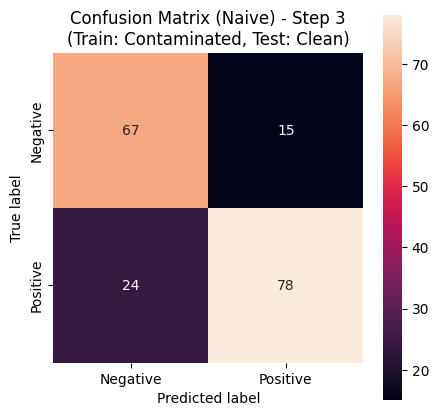


===== Training Decision Tree (Naive) at Step 4 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 4 | Training time (Naive): 0.0027 sec
Step 4 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.7934782608695652
Precision: 0.8636363636363636
Recall: 0.7450980392156863
F1-score: 0.8


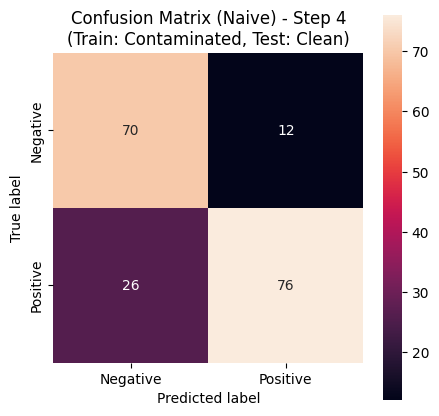


===== Training Decision Tree (Naive) at Step 5 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 5 | Training time (Naive): 0.0028 sec
Step 5 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.8097826086956522
Precision: 0.8018018018018018
Recall: 0.8725490196078431
F1-score: 0.8356807511737089


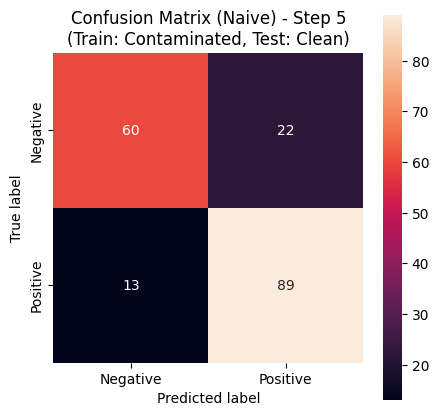


===== Training Decision Tree (Naive) at Step 6 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 6 | Training time (Naive): 0.0027 sec
Step 6 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.8152173913043478
Precision: 0.8207547169811321
Recall: 0.8529411764705882
F1-score: 0.8365384615384616


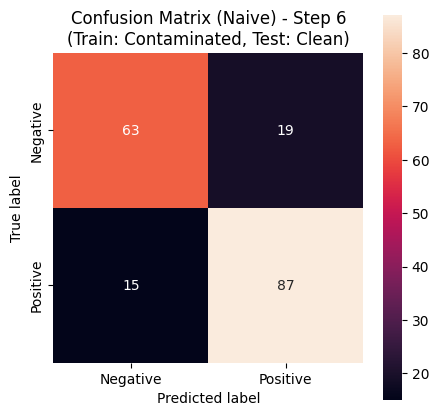


===== Training Decision Tree (Naive) at Step 7 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 7 | Training time (Naive): 0.0037 sec
Step 7 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.842391304347826
Precision: 0.8411214953271028
Recall: 0.8823529411764706
F1-score: 0.861244019138756


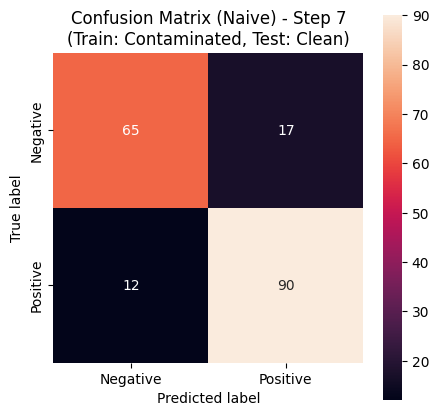


===== Training Decision Tree (Naive) at Step 8 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 8 | Training time (Naive): 0.0035 sec
Step 8 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.8152173913043478
Precision: 0.8035714285714286
Recall: 0.8823529411764706
F1-score: 0.8411214953271028


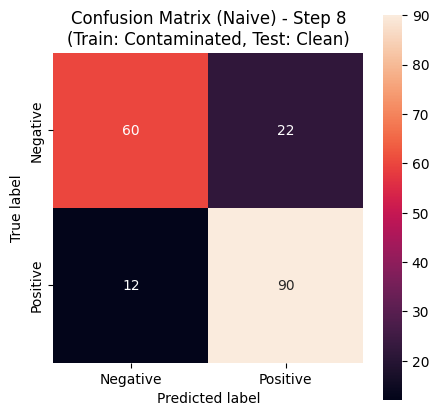


===== Training Decision Tree (Naive) at Step 9 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 9 | Training time (Naive): 0.0041 sec
Step 9 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.8206521739130435
Precision: 0.8709677419354839
Recall: 0.7941176470588235
F1-score: 0.8307692307692308


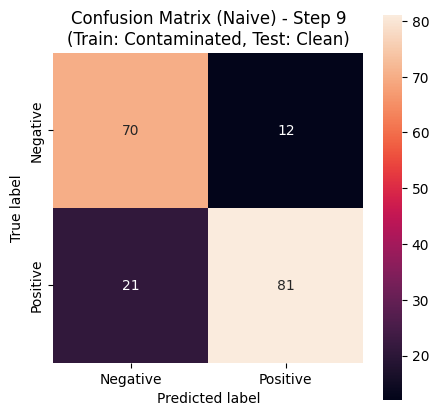


===== Training Decision Tree (Naive) at Step 10 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 10 | Training time (Naive): 0.0029 sec
Step 10 | Training Accuracy (Naive): 1.0000
Misure di performance globali decision tree naive

Accuracy: 0.8641304347826086
Precision: 0.8666666666666667
Recall: 0.8921568627450981
F1-score: 0.8792270531400966


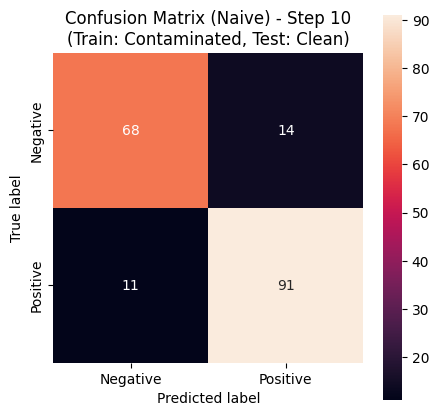



DECISION TREE - OPTIMIZED


===== Training Decision Tree (Optimized) at Step 0 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Step 0 | Training time (Optimized): 0.0009 sec
Step 0 | Training Accuracy (Optimized): 0.8542
Misure di performance globali decision tree optimized

Accuracy: 0.8315217391304348
Precision: 0.8380952380952381
Recall: 0.8627450980392157
F1-score: 0.8502415458937198


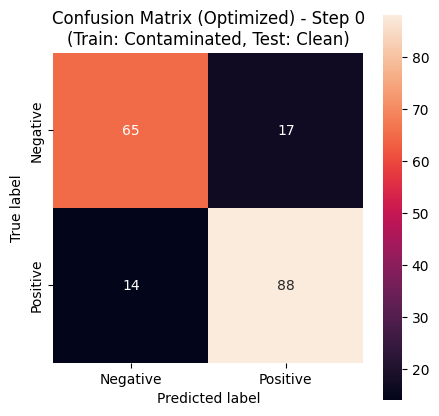


===== Training Decision Tree (Optimized) at Step 1 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 1 | Training time (Optimized): 0.0013 sec
Step 1 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


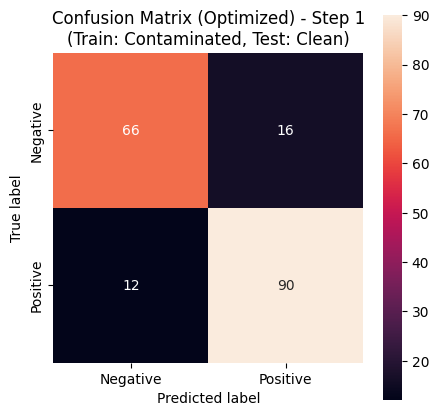


===== Training Decision Tree (Optimized) at Step 2 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 2 | Training time (Optimized): 0.0021 sec
Step 2 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


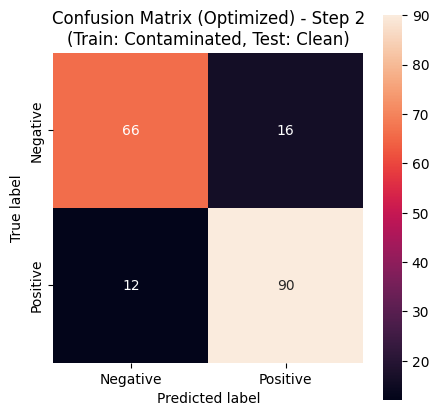


===== Training Decision Tree (Optimized) at Step 3 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 3 | Training time (Optimized): 0.0015 sec
Step 3 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


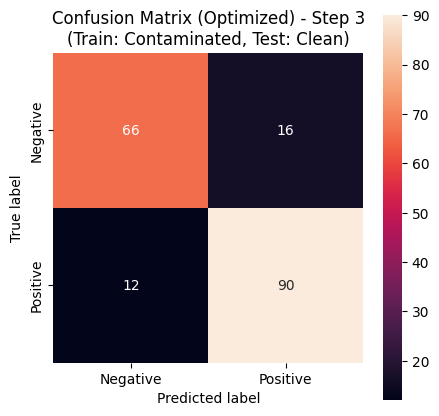


===== Training Decision Tree (Optimized) at Step 4 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 4 | Training time (Optimized): 0.0019 sec
Step 4 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


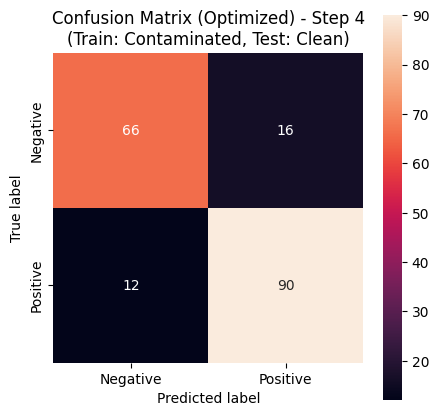


===== Training Decision Tree (Optimized) at Step 5 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 5 | Training time (Optimized): 0.0017 sec
Step 5 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


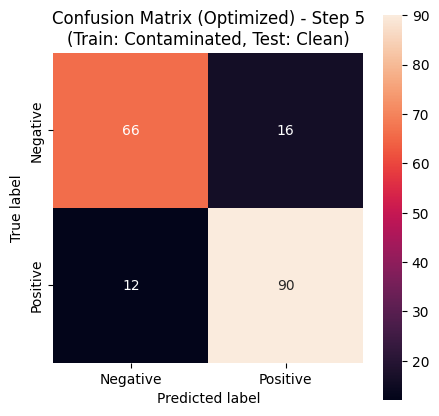


===== Training Decision Tree (Optimized) at Step 6 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 6 | Training time (Optimized): 0.0017 sec
Step 6 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


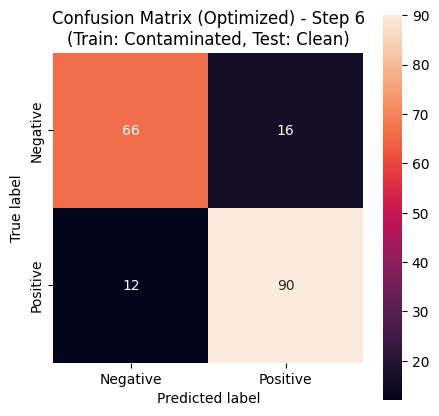


===== Training Decision Tree (Optimized) at Step 7 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 7 | Training time (Optimized): 0.0014 sec
Step 7 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


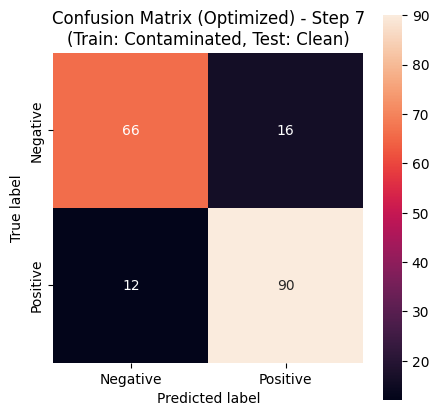


===== Training Decision Tree (Optimized) at Step 8 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 8 | Training time (Optimized): 0.0012 sec
Step 8 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


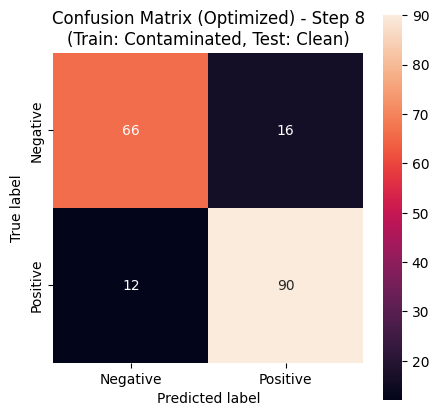


===== Training Decision Tree (Optimized) at Step 9 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 9 | Training time (Optimized): 0.0016 sec
Step 9 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


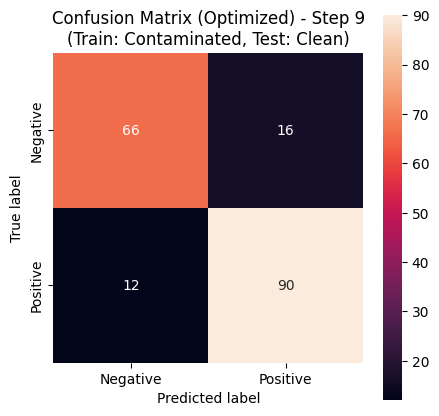


===== Training Decision Tree (Optimized) at Step 10 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 10 | Training time (Optimized): 0.0018 sec
Step 10 | Training Accuracy (Optimized): 0.8529
Misure di performance globali decision tree optimized

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1-score: 0.8653846153846154


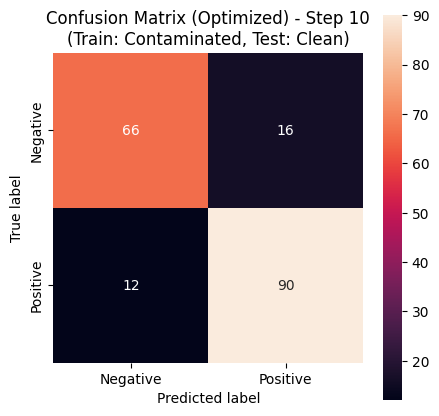



SVM - NAIVE


===== Training SVM (Naive) at Step 0 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Step 0 | Training time (Naive): 0.0185 sec
Step 0 | Training Accuracy (Naive): 0.8965
Misure di performance globali svm naive

Accuracy: 0.8695652173913043
Precision: 0.8823529411764706
Recall: 0.8823529411764706
F1-score: 0.8823529411764706


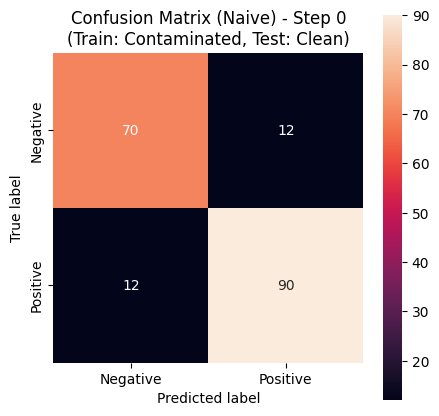


===== Training SVM (Naive) at Step 1 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 1 | Training time (Naive): 0.0117 sec
Step 1 | Training Accuracy (Naive): 0.8965
Misure di performance globali svm naive

Accuracy: 0.875
Precision: 0.883495145631068
Recall: 0.8921568627450981
F1-score: 0.8878048780487805


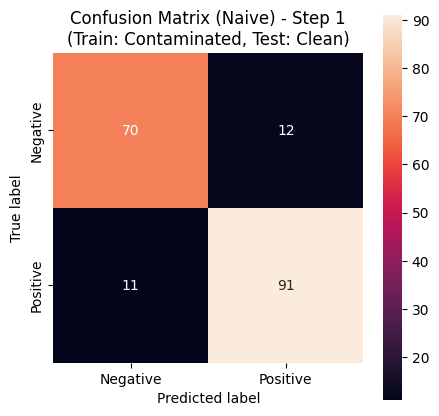


===== Training SVM (Naive) at Step 2 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 2 | Training time (Naive): 0.0109 sec
Step 2 | Training Accuracy (Naive): 0.9019
Misure di performance globali svm naive

Accuracy: 0.8641304347826086
Precision: 0.8737864077669902
Recall: 0.8823529411764706
F1-score: 0.8780487804878049


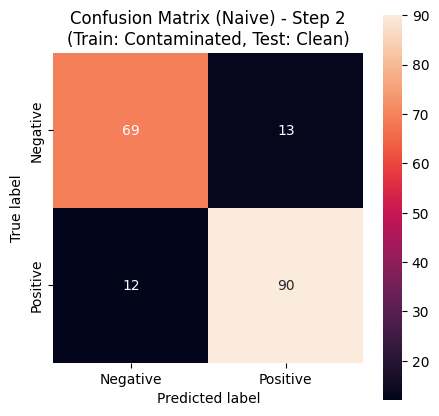


===== Training SVM (Naive) at Step 3 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 3 | Training time (Naive): 0.0080 sec
Step 3 | Training Accuracy (Naive): 0.8937
Misure di performance globali svm naive

Accuracy: 0.8532608695652174
Precision: 0.8640776699029126
Recall: 0.8725490196078431
F1-score: 0.8682926829268293


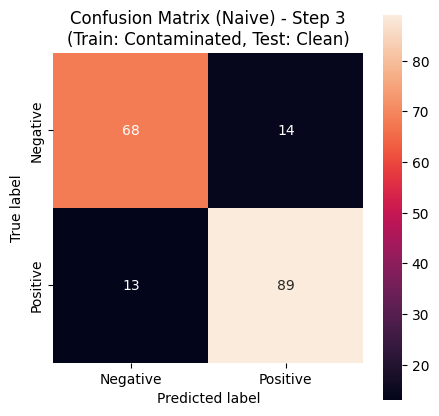


===== Training SVM (Naive) at Step 4 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 4 | Training time (Naive): 0.0156 sec
Step 4 | Training Accuracy (Naive): 0.8924
Misure di performance globali svm naive

Accuracy: 0.8532608695652174
Precision: 0.8504672897196262
Recall: 0.8921568627450981
F1-score: 0.8708133971291866


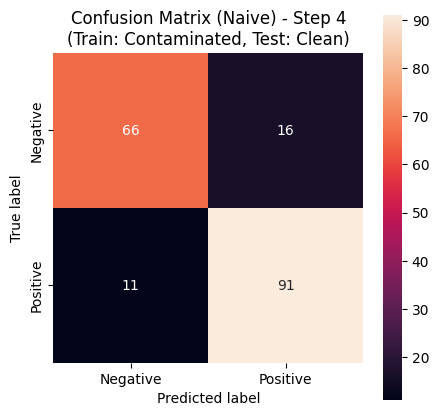


===== Training SVM (Naive) at Step 5 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 5 | Training time (Naive): 0.0218 sec
Step 5 | Training Accuracy (Naive): 0.8815
Misure di performance globali svm naive

Accuracy: 0.8260869565217391
Precision: 0.8181818181818182
Recall: 0.8823529411764706
F1-score: 0.8490566037735849


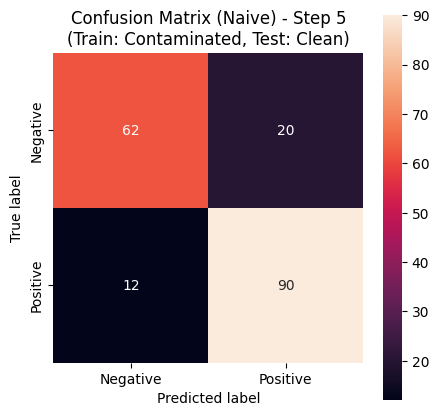


===== Training SVM (Naive) at Step 6 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 6 | Training time (Naive): 0.0319 sec
Step 6 | Training Accuracy (Naive): 0.8815
Misure di performance globali svm naive

Accuracy: 0.8206521739130435
Precision: 0.8285714285714286
Recall: 0.8529411764705882
F1-score: 0.8405797101449275


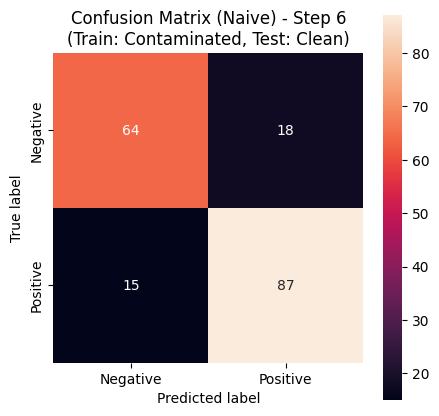


===== Training SVM (Naive) at Step 7 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 7 | Training time (Naive): 0.0202 sec
Step 7 | Training Accuracy (Naive): 0.8924
Misure di performance globali svm naive

Accuracy: 0.8260869565217391
Precision: 0.85
Recall: 0.8333333333333334
F1-score: 0.8415841584158416


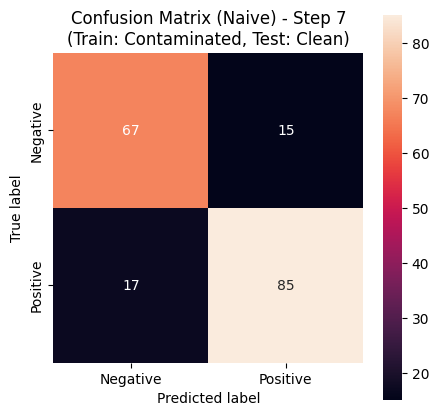


===== Training SVM (Naive) at Step 8 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 8 | Training time (Naive): 0.0102 sec
Step 8 | Training Accuracy (Naive): 0.8910
Misure di performance globali svm naive

Accuracy: 0.842391304347826
Precision: 0.8762886597938144
Recall: 0.8333333333333334
F1-score: 0.8542713567839196


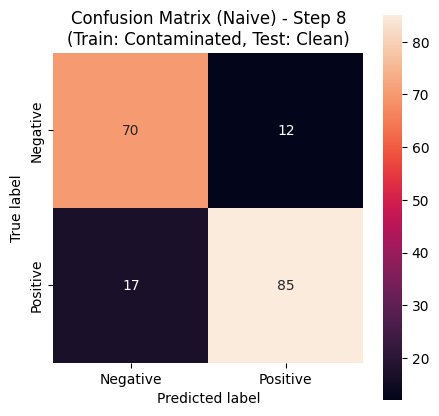


===== Training SVM (Naive) at Step 9 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 9 | Training time (Naive): 0.0095 sec
Step 9 | Training Accuracy (Naive): 0.8869
Misure di performance globali svm naive

Accuracy: 0.8369565217391305
Precision: 0.8673469387755102
Recall: 0.8333333333333334
F1-score: 0.85


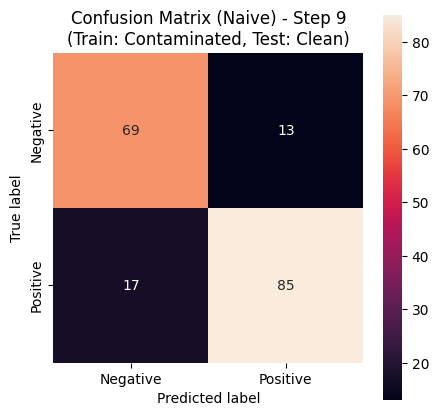


===== Training SVM (Naive) at Step 10 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 10 | Training time (Naive): 0.0074 sec
Step 10 | Training Accuracy (Naive): 0.8787
Misure di performance globali svm naive

Accuracy: 0.8369565217391305
Precision: 0.839622641509434
Recall: 0.8725490196078431
F1-score: 0.8557692307692307


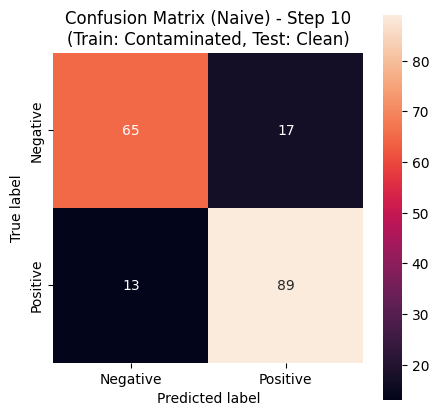



SVM - OPTIMIZED


===== Training SVM (Optimized) at Step 0 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Step 0 | Training time (Optimized): 0.0070 sec
Step 0 | Training Accuracy (Optimized): 0.8842
Misure di performance globali svm optimized

Accuracy: 0.875
Precision: 0.883495145631068
Recall: 0.8921568627450981
F1-score: 0.8878048780487805


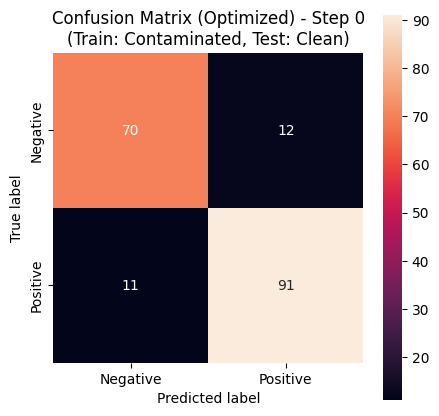


===== Training SVM (Optimized) at Step 1 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 1 | Training time (Optimized): 0.0088 sec
Step 1 | Training Accuracy (Optimized): 0.8774
Misure di performance globali svm optimized

Accuracy: 0.842391304347826
Precision: 0.8686868686868687
Recall: 0.8431372549019608
F1-score: 0.8557213930348259


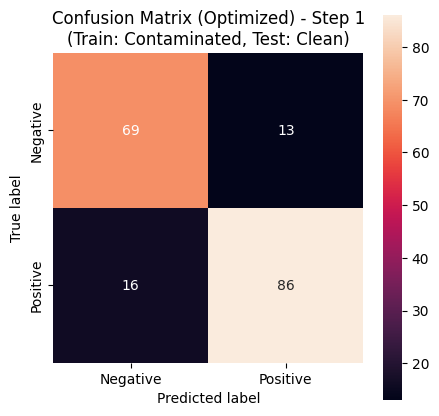


===== Training SVM (Optimized) at Step 2 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 2 | Training time (Optimized): 0.0088 sec
Step 2 | Training Accuracy (Optimized): 0.8624
Misure di performance globali svm optimized

Accuracy: 0.8369565217391305
Precision: 0.86
Recall: 0.8431372549019608
F1-score: 0.8514851485148515


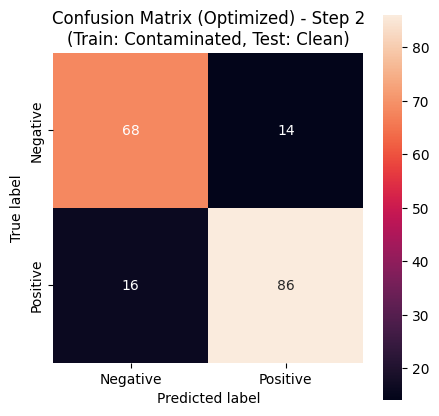


===== Training SVM (Optimized) at Step 3 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 3 | Training time (Optimized): 0.0077 sec
Step 3 | Training Accuracy (Optimized): 0.8665
Misure di performance globali svm optimized

Accuracy: 0.8369565217391305
Precision: 0.875
Recall: 0.8235294117647058
F1-score: 0.8484848484848485


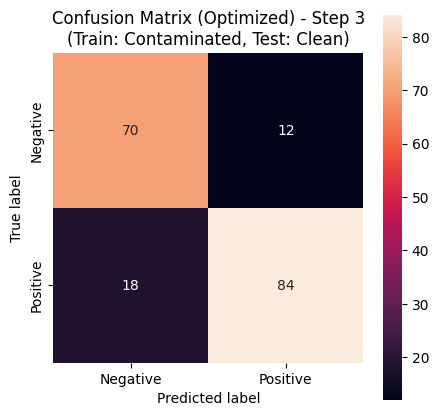


===== Training SVM (Optimized) at Step 4 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 4 | Training time (Optimized): 0.0096 sec
Step 4 | Training Accuracy (Optimized): 0.8597
Misure di performance globali svm optimized

Accuracy: 0.8369565217391305
Precision: 0.8673469387755102
Recall: 0.8333333333333334
F1-score: 0.85


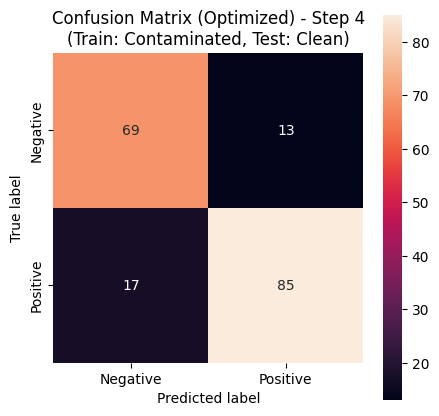


===== Training SVM (Optimized) at Step 5 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 5 | Training time (Optimized): 0.0081 sec
Step 5 | Training Accuracy (Optimized): 0.8556
Misure di performance globali svm optimized

Accuracy: 0.842391304347826
Precision: 0.8543689320388349
Recall: 0.8627450980392157
F1-score: 0.8585365853658536


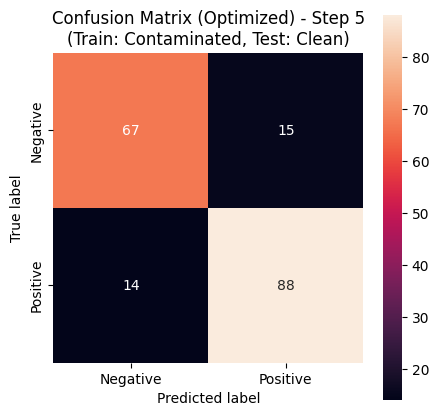


===== Training SVM (Optimized) at Step 6 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 6 | Training time (Optimized): 0.0066 sec
Step 6 | Training Accuracy (Optimized): 0.8624
Misure di performance globali svm optimized

Accuracy: 0.8478260869565217
Precision: 0.8557692307692307
Recall: 0.8725490196078431
F1-score: 0.8640776699029126


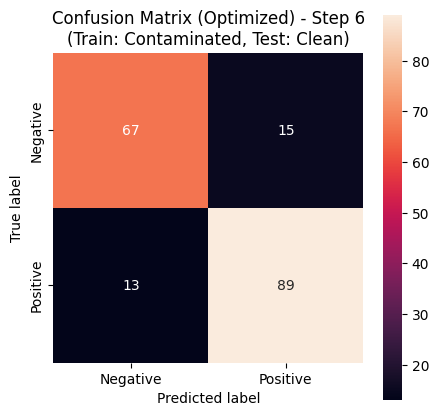


===== Training SVM (Optimized) at Step 7 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 7 | Training time (Optimized): 0.0081 sec
Step 7 | Training Accuracy (Optimized): 0.8678
Misure di performance globali svm optimized

Accuracy: 0.8315217391304348
Precision: 0.8585858585858586
Recall: 0.8333333333333334
F1-score: 0.845771144278607


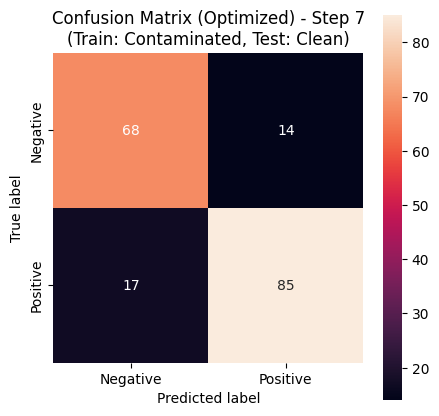


===== Training SVM (Optimized) at Step 8 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 8 | Training time (Optimized): 0.0116 sec
Step 8 | Training Accuracy (Optimized): 0.8706
Misure di performance globali svm optimized

Accuracy: 0.8260869565217391
Precision: 0.8804347826086957
Recall: 0.7941176470588235
F1-score: 0.8350515463917526


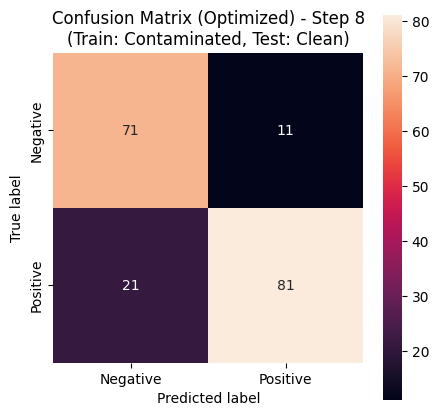


===== Training SVM (Optimized) at Step 9 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 9 | Training time (Optimized): 0.0103 sec
Step 9 | Training Accuracy (Optimized): 0.8747
Misure di performance globali svm optimized

Accuracy: 0.8369565217391305
Precision: 0.8529411764705882
Recall: 0.8529411764705882
F1-score: 0.8529411764705882


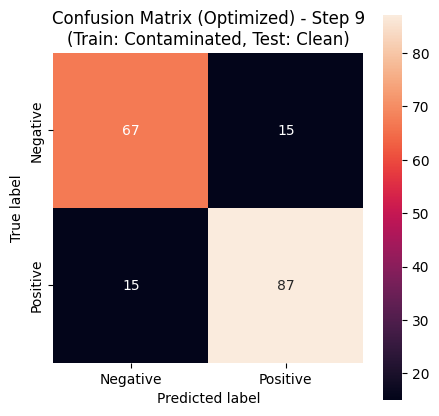


===== Training SVM (Optimized) at Step 10 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 10 | Training time (Optimized): 0.0077 sec
Step 10 | Training Accuracy (Optimized): 0.8706
Misure di performance globali svm optimized

Accuracy: 0.842391304347826
Precision: 0.8543689320388349
Recall: 0.8627450980392157
F1-score: 0.8585365853658536


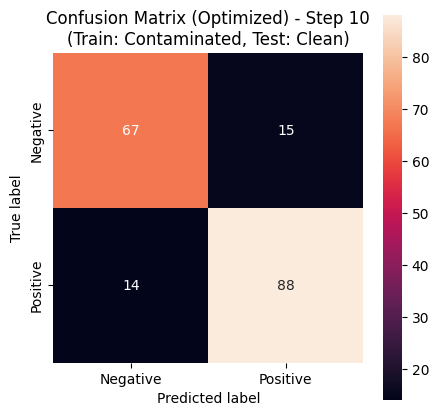



NEURAL NETWORK - NAIVE


===== Training Neural Network (Naive) at Step 0 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Step 0 | Training time (Naive): 5.6171 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Step 0 | Training Accuracy (Naive): 0.9796
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Misure di performance globali neural network naive

Accuracy: 0.8152173913043478
Precision: 0.8541666666666666
Recall: 0.803921568627451
F1-score: 0.8282828282828283


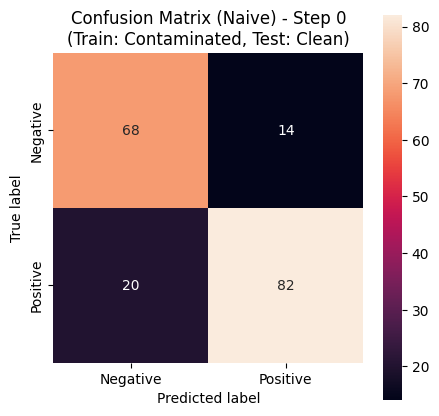

Final validation accuracy: 0.8152
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 1 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 1 | Training time (Naive): 4.7632 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 1 | Training Accuracy (Naive): 0.9700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network naive

Accuracy: 0.8369565217391305
Precision: 0.8673469387755102
Recall: 0.8333333333333334
F1-score: 0.85


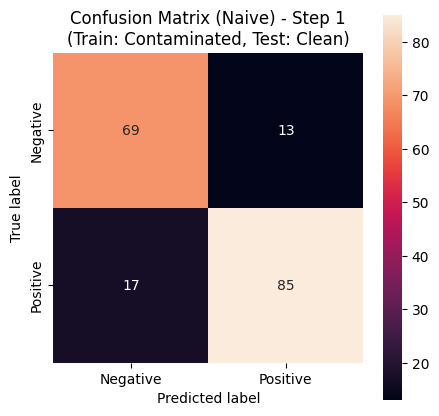

Final validation accuracy: 0.8370
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 2 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 2 | Training time (Naive): 4.0412 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 2 | Training Accuracy (Naive): 0.9700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network naive

Accuracy: 0.8532608695652174
Precision: 0.9032258064516129
Recall: 0.8235294117647058
F1-score: 0.8615384615384616


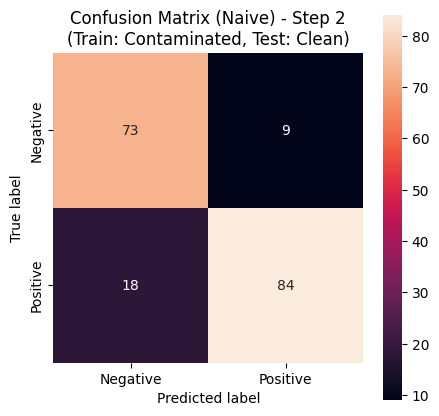

Final validation accuracy: 0.8533
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 3 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 3 | Training time (Naive): 4.5083 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Step 3 | Training Accuracy (Naive): 0.9768
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network naive

Accuracy: 0.8260869565217391
Precision: 0.8571428571428571
Recall: 0.8235294117647058
F1-score: 0.84


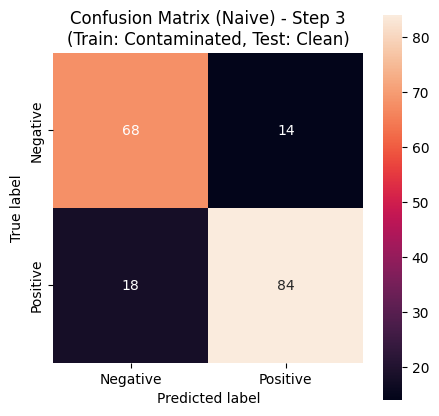

Final validation accuracy: 0.8261
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 4 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 4 | Training time (Naive): 4.9744 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Step 4 | Training Accuracy (Naive): 0.9850
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Misure di performance globali neural network naive

Accuracy: 0.842391304347826
Precision: 0.8613861386138614
Recall: 0.8529411764705882
F1-score: 0.8571428571428571


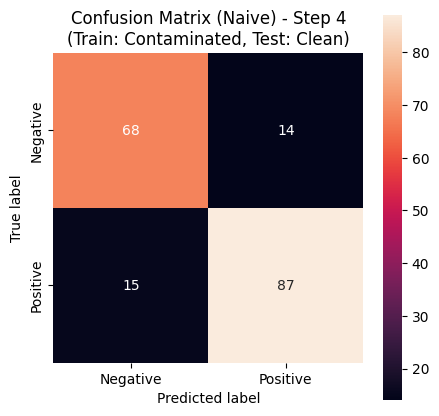

Final validation accuracy: 0.8424
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 5 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 5 | Training time (Naive): 4.4547 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 5 | Training Accuracy (Naive): 0.9741
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Misure di performance globali neural network naive

Accuracy: 0.8641304347826086
Precision: 0.8347826086956521
Recall: 0.9411764705882353
F1-score: 0.8847926267281107


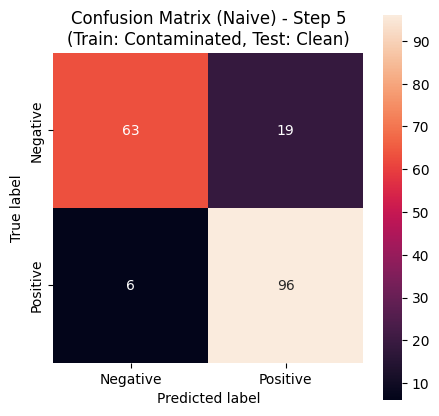

Final validation accuracy: 0.8641
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 6 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 6 | Training time (Naive): 4.2290 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 6 | Training Accuracy (Naive): 0.9768
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network naive

Accuracy: 0.8369565217391305
Precision: 0.8333333333333334
Recall: 0.8823529411764706
F1-score: 0.8571428571428571


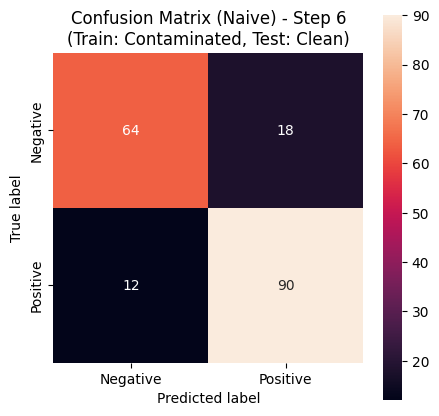

Final validation accuracy: 0.8370
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 7 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 7 | Training time (Naive): 4.1162 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 7 | Training Accuracy (Naive): 0.9837
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Misure di performance globali neural network naive

Accuracy: 0.8260869565217391
Precision: 0.8431372549019608
Recall: 0.8431372549019608
F1-score: 0.8431372549019608


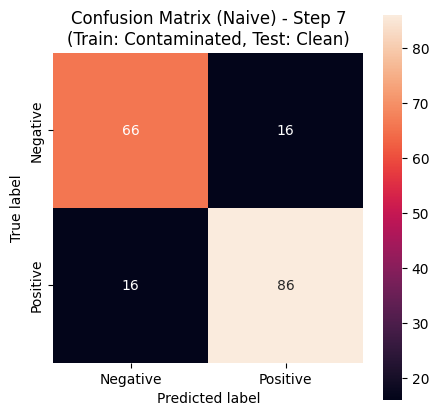

Final validation accuracy: 0.8261
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 8 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 8 | Training time (Naive): 3.8900 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 8 | Training Accuracy (Naive): 0.9823
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Misure di performance globali neural network naive

Accuracy: 0.8043478260869565
Precision: 0.8586956521739131
Recall: 0.7745098039215687
F1-score: 0.8144329896907216


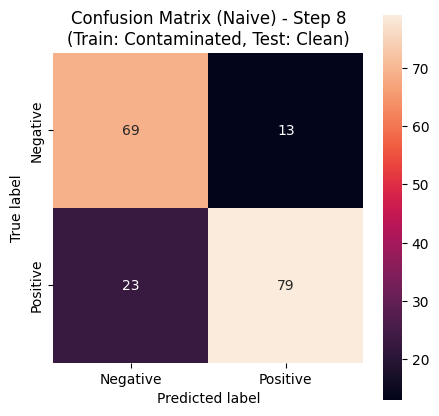

Final validation accuracy: 0.8043
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 9 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 9 | Training time (Naive): 3.9059 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Step 9 | Training Accuracy (Naive): 0.9823
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Misure di performance globali neural network naive

Accuracy: 0.8695652173913043
Precision: 0.8545454545454545
Recall: 0.9215686274509803
F1-score: 0.8867924528301887


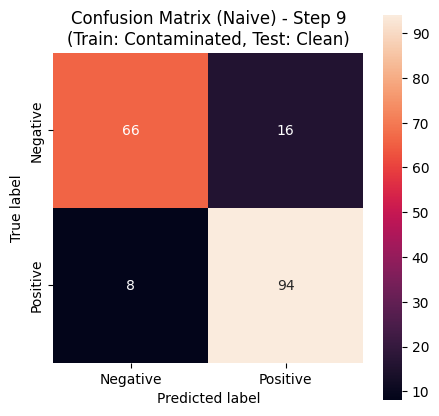

Final validation accuracy: 0.8696
Training epochs completed: 50

===== Training Neural Network (Naive) at Step 10 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 10 | Training time (Naive): 4.0392 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 10 | Training Accuracy (Naive): 0.9537
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network naive

Accuracy: 0.8641304347826086
Precision: 0.8407079646017699
Recall: 0.9313725490196079
F1-score: 0.8837209302325582


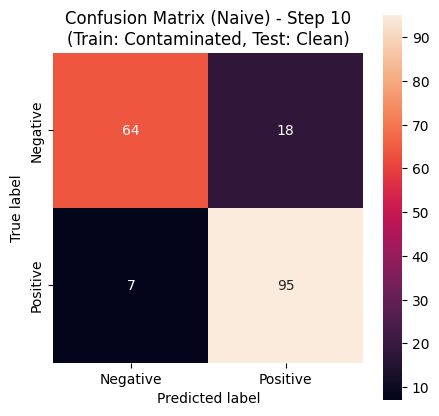

Final validation accuracy: 0.8641
Training epochs completed: 50


NEURAL NETWORK - OPTIMIZED


===== Training Neural Network (Optimized) at Step 0 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Step 0 | Training time (Optimized): 6.7955 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 0 | Training Accuracy (Optimized): 0.9183
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.8641304347826086
Precision: 0.8737864077669902
Recall: 0.8823529411764706
F1-score: 0.8780487804878049


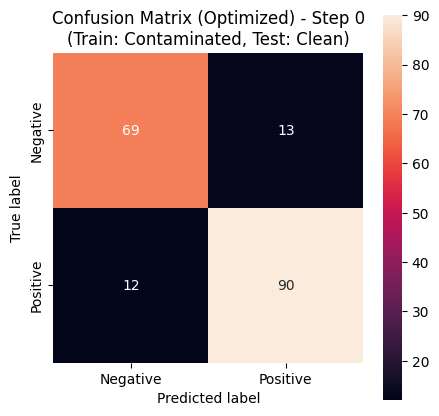

Final validation accuracy: 0.8641
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 1 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 1 | Training time (Optimized): 6.3059 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 1 | Training Accuracy (Optimized): 0.9114
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Misure di performance globali neural network optimized

Accuracy: 0.8532608695652174
Precision: 0.8571428571428571
Recall: 0.8823529411764706
F1-score: 0.8695652173913043


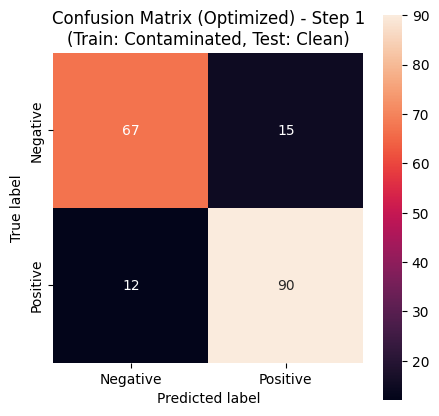

Final validation accuracy: 0.8533
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 2 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 2 | Training time (Optimized): 8.3556 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 2 | Training Accuracy (Optimized): 0.9060
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Misure di performance globali neural network optimized

Accuracy: 0.8532608695652174
Precision: 0.8640776699029126
Recall: 0.8725490196078431
F1-score: 0.8682926829268293


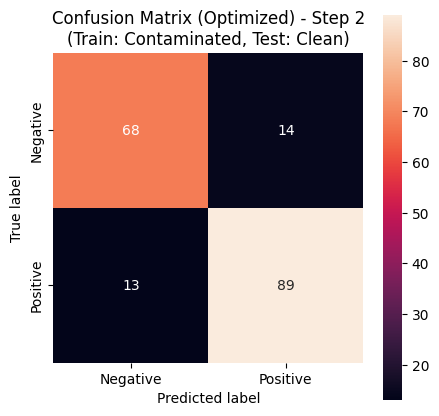

Final validation accuracy: 0.8533
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 3 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 3 | Training time (Optimized): 9.0853 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 3 | Training Accuracy (Optimized): 0.9128
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Misure di performance globali neural network optimized

Accuracy: 0.875
Precision: 0.8761904761904762
Recall: 0.9019607843137255
F1-score: 0.8888888888888888


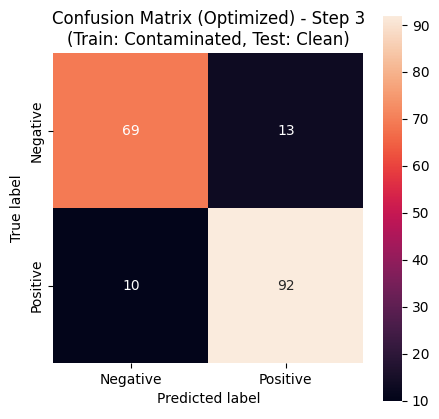

Final validation accuracy: 0.8750
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 4 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 4 | Training time (Optimized): 7.4942 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 4 | Training Accuracy (Optimized): 0.9237
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.8913043478260869
Precision: 0.8867924528301887
Recall: 0.9215686274509803
F1-score: 0.9038461538461539


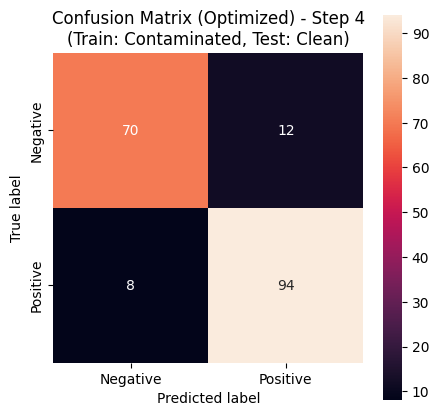

Final validation accuracy: 0.8913
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 5 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 5 | Training time (Optimized): 6.4934 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Step 5 | Training Accuracy (Optimized): 0.9074
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.8695652173913043
Precision: 0.8482142857142857
Recall: 0.9313725490196079
F1-score: 0.8878504672897196


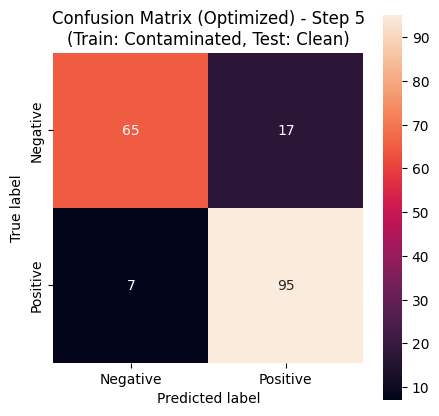

Final validation accuracy: 0.8696
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 6 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 6 | Training time (Optimized): 6.6911 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Step 6 | Training Accuracy (Optimized): 0.9033
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.8804347826086957
Precision: 0.8571428571428571
Recall: 0.9411764705882353
F1-score: 0.897196261682243


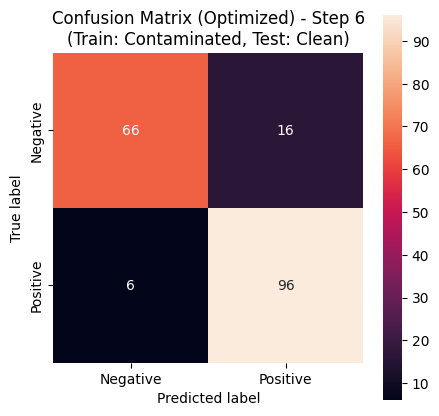

Final validation accuracy: 0.8804
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 7 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 7 | Training time (Optimized): 6.6293 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 7 | Training Accuracy (Optimized): 0.9087
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Misure di performance globali neural network optimized

Accuracy: 0.8695652173913043
Precision: 0.8611111111111112
Recall: 0.9117647058823529
F1-score: 0.8857142857142857


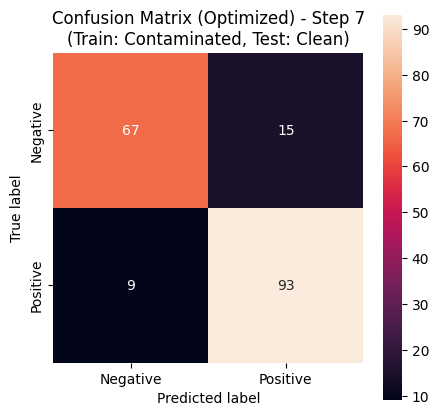

Final validation accuracy: 0.8696
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 8 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 8 | Training time (Optimized): 7.2233 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Step 8 | Training Accuracy (Optimized): 0.9114
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.8858695652173914
Precision: 0.8857142857142857
Recall: 0.9117647058823529
F1-score: 0.8985507246376812


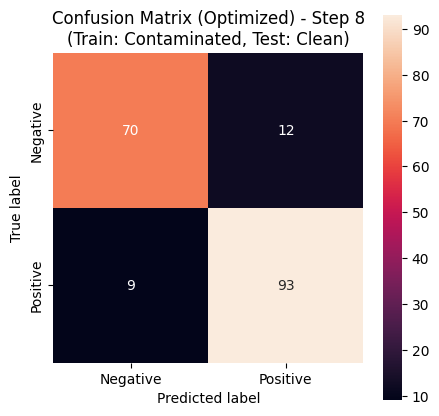

Final validation accuracy: 0.8859
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 9 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 9 | Training time (Optimized): 8.0871 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Step 9 | Training Accuracy (Optimized): 0.9033
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.8804347826086957
Precision: 0.8636363636363636
Recall: 0.9313725490196079
F1-score: 0.8962264150943396


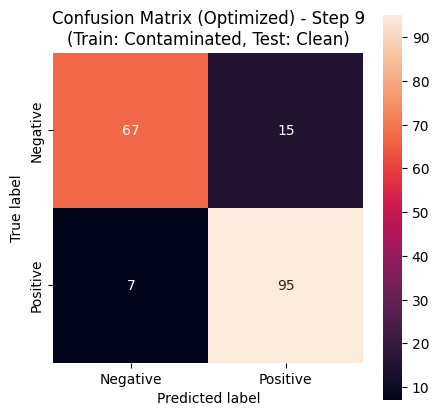

Final validation accuracy: 0.8804
Training epochs completed: 100

===== Training Neural Network (Optimized) at Step 10 =====
Training set size: 734 samples (contaminated)
Test set size: 184 samples (clean)
Rows with at least one contaminated value in training set: 734/734
Total contaminated values in training set: 3670/3670
Contamination rate: 1.000
Contamination by feature:
  Age: 734/734 (1.000)
  RestingBP: 734/734 (1.000)
  Cholesterol: 734/734 (1.000)
  MaxHR: 734/734 (1.000)
  Oldpeak: 734/734 (1.000)
Step 10 | Training time (Optimized): 8.9991 sec
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Step 10 | Training Accuracy (Optimized): 0.8992
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Misure di performance globali neural network optimized

Accuracy: 0.875
Precision: 0.8623853211009175
Recall: 0.9215686274509803
F1-score: 0.8909952606635071


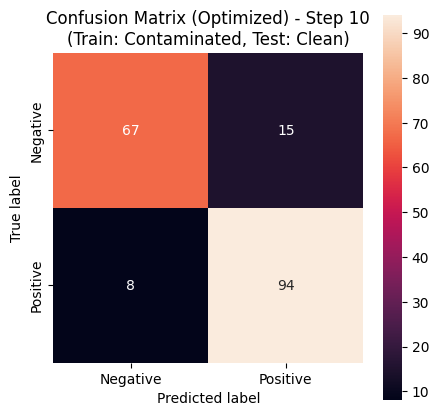

Final validation accuracy: 0.8750
Training epochs completed: 100


In [612]:
#import shap
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
import random
import os
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import optimizers

best_dt_params = joblib.load('best_decision_tree_model.pkl')

best_svm_params = joblib.load('best_svm_model.pkl')

svm_model = make_pipeline(
    ColumnTransformer([
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', binary_features)
    ]),
    svm.SVC(random_state=42, probability=True) 
)

svm_optimized = make_pipeline(
    ColumnTransformer([
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', binary_features)
    ]),
    svm.SVC(**best_svm_params, random_state=42)
)

# Parametri ottimizzati per il modello di deep learning personalizzato
best_nn_params = {
    'activation': 'relu',
    'batch_size': 32,
    'dropout_rate': 0.3,
    'random_state': 42,
    'epochs': 100,
    'hidden_layer_sizes': (100,),
    'optimizer': 'adam',
    'verbose': 0
}

X_original = df.drop('HeartDisease', axis=1)  # df è il dataset originale pulito
y_original = df['HeartDisease']

# Split del dataset originale per ottenere il test set pulito
X_temp, X_test_clean, y_temp, y_test_clean = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42, stratify=y_original
)

feature_importances = {}
confusion_matrix_values = {}


class CustomNeuralNetwork:
    def __init__(self, activation, batch_size, dropout_rate, 
                 epochs, hidden_layer_sizes, optimizer,
                 learning_rate, verbose, random_state=42):
        
        # Imposta i semi per la riproducibilità
        tf.random.set_seed(random_state)
        np.random.seed(random_state)
        random.seed(random_state)
        os.environ['PYTHONHASHSEED'] = str(random_state)
        
        self.activation = activation
        self.batch_size = batch_size
        self.dropout_rate = dropout_rate
        self.epochs = epochs
        self.hidden_layer_sizes = hidden_layer_sizes
        self.optimizer = optimizer
        self.learning_rate = learning_rate
        self.verbose = verbose
        self.random_state = random_state
        self.model = None
        self.history = None
        self.scaler = StandardScaler()
    
    def _build_model(self, input_dim):
        
        model = Sequential()
        
        if len(self.hidden_layer_sizes) == 1:
            # Caso ottimizzato: (50,) → Dense(50) → Dense(1)
            model.add(Dense(self.hidden_layer_sizes[0], 
                           activation=self.activation, 
                           input_shape=(input_dim,)))
            model.add(Dropout(self.dropout_rate))
            model.add(Dense(1, activation='sigmoid'))    
            
        elif len(self.hidden_layer_sizes) == 2:
            # Caso naive: (100, 50) → Dense(100) → Dense(50) → Dense(1)
            model.add(Dense(self.hidden_layer_sizes[0], 
                           activation=self.activation, 
                           input_shape=(input_dim,)))
            model.add(Dense(self.hidden_layer_sizes[1], 
                           activation=self.activation))
            model.add(Dense(1, activation='sigmoid'))
        else:
            # Fallback generico
            model.add(Dense(self.hidden_layer_sizes[0], 
                           activation=self.activation, 
                           input_shape=(input_dim,)))
            
            for units in self.hidden_layer_sizes[1:]:
                model.add(Dense(units, activation=self.activation))
            
            model.add(Dense(1, activation='sigmoid'))
        
        # Compilazione
        selected_optimizer = optimizers.get(self.optimizer)
        model.compile(optimizer=selected_optimizer,
                    loss=BinaryCrossentropy(), 
                    metrics=['accuracy'])
        
        return model
    
    def fit(self, X, y, X_validation=None, y_validation=None):
        """
        Parameters:
        -----------
        X, y : training data
        X_validation, y_validation : validation data (se forniti, usa validation_data invece di validation_split)
        """
        # Normalizza solo le feature continue
        X_processed = X.copy()
        X_processed[continuous_features] = self.scaler.fit_transform(X[continuous_features])
        
        # Costruisce il modello
        input_dim = X_processed.shape[1]
        self.model = self._build_model(input_dim)
        
        # Preprocessa anche i dati di validazione se forniti
        if X_validation is not None and y_validation is not None:
            X_val_processed = X_validation.copy()
            X_val_processed[continuous_features] = self.scaler.transform(X_validation[continuous_features])
            validation_data = (X_val_processed, y_validation)
        else:
            validation_data = None
        
        if validation_data is not None:
            self.history = self.model.fit(
                X_processed, y,
                epochs=self.epochs,
                batch_size=self.batch_size,
                validation_data=validation_data,  
                verbose=self.verbose
            )
        else:
            # Fallback: senza validazione
            self.history = self.model.fit(
                X_processed, y,
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=self.verbose
            )
        
        return self
    
    def predict(self, X):
        """Fa predizioni"""
        X_processed = X.copy()
        X_processed[continuous_features] = self.scaler.transform(X[continuous_features])
        
        predictions = self.model.predict(X_processed).ravel()  # .ravel() come primo codice
        return (predictions > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Restituisce le probabilità predette"""
        X_processed = X.copy()
        X_processed[continuous_features] = self.scaler.transform(X[continuous_features])
        
        probabilities = self.model.predict(X_processed).ravel()
        return np.column_stack([1 - probabilities, probabilities])
    
    def score(self, X, y):
        """Calcola l'accuracy"""
        predictions = self.predict(X)
        return (predictions == y).mean()

def train_and_evaluate_model(datasets, X_test_clean, y_test_clean, 
                             model_class, model_params, model_name, 
                             approach_name, timing_collector, 
                             all_metrics_list, generator=None,
                             continuous_features=None):
          
    print(f"\n\n======================")
    print(f"{model_name.upper()} - {approach_name.upper()}")
    print(f"======================\n")

    cm_key = f"{model_name} - {approach_name}"
    if cm_key not in confusion_matrix_values:
        confusion_matrix_values[cm_key] = {}
    
    for step_idx, contaminated_df in enumerate(datasets):
        print(f"\n===== Training {model_name} ({approach_name}) at Step {step_idx} =====")
        
        X_contaminated = contaminated_df.drop('HeartDisease', axis=1)
        y_contaminated = contaminated_df['HeartDisease']
        
        X_train_contaminated, _, y_train_contaminated, _ = train_test_split(
            X_contaminated, y_contaminated, test_size=0.2, random_state=42, stratify=y_contaminated
        )
        
        X_train = X_train_contaminated.copy()
        X_test = X_test_clean.copy()
        
        # Preprocessazione per SVM
        if model_name == 'SVM':
            scaler = StandardScaler()
            X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
            X_test[continuous_features] = scaler.transform(X_test[continuous_features])
        
        y_train = y_train_contaminated
        y_test = y_test_clean
        
        print(f"Training set size: {len(X_train)} samples (contaminated)")
        print(f"Test set size: {len(X_test)} samples (clean)")
        
        # Statistiche contaminazione (uguale a prima)
        if step_idx > 0 and generator is not None:
            contaminated_rows = count_contaminated_rows_in_training(generator, X_train.index)
            print(f"Rows with at least one contaminated value in training set: {contaminated_rows}/{len(X_train)}")
            
            if continuous_features is not None:
                contamination_stats = count_contaminated_values_in_training(
                    generator, X_train.index, continuous_features
                )
                print(f"Total contaminated values in training set: {contamination_stats['total_contaminated_values']}/{contamination_stats['total_training_values']}")
                print(f"Contamination rate: {contamination_stats['total_contaminated_values']/contamination_stats['total_training_values']:.3f}")
                
                print("Contamination by feature:")
                for feature, count in contamination_stats['contamination_by_feature'].items():
                    feature_total = len(X_train)
                    rate = count / feature_total if feature_total > 0 else 0
                    print(f"  {feature}: {count}/{feature_total} ({rate:.3f})")
        
        # Creazione del modello
        if model_class == svm.SVC:
            if approach_name == "Naive":
                model = svm.SVC(**model_params)
            elif approach_name == "Optimized":
                model = svm.SVC(**best_svm_params)
        else:
            model = model_class(**model_params)
        
        start_time = time.time()
        
        if model_name == 'Neural Network':
            # Addestra con validation_data come nel primo codice
            model.fit(X_train, y_train, X_validation=X_test, y_validation=y_test)
        else:
            model.fit(X_train, y_train)
            
        end_time = time.time()
        
        training_time = end_time - start_time
        print(f"Step {step_idx} | Training time ({approach_name}): {training_time:.4f} sec")
        
        timing_key = f"{model_name.lower().replace(' ', '_')}_{approach_name.lower()}_training_step_{step_idx}"
        timing_collector[timing_key] = training_time
        
        accuracy_train = model.score(X_train, y_train)
        print(f"Step {step_idx} | Training Accuracy ({approach_name}): {accuracy_train:.4f}")
        
        y_pred = model.predict(X_test)
        
        metrics = calculate_metrics(y_test, y_pred, model_name, approach_name, step_idx)
        metrics['training_time'] = training_time
        metrics['train_accuracy'] = accuracy_train
        metrics['contamination_step'] = step_idx
        metrics['test_set_type'] = 'clean'
        
        all_metrics_list.append(metrics)
        
        # Confusion matrix (uguale a prima)
        cm = confusion_matrix(y_test, y_pred)
        TN, FP, FN, TP = cm.ravel()
        confusion_matrix_values[cm_key][step_idx] = {
            'TN': int(TN),
            'FP': int(FP),  
            'FN': int(FN),
            'TP': int(TP),
            'confusion_matrix': cm.tolist()
        }

        plt.figure(figsize=(5,5))
        sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                   xticklabels=['Negative', 'Positive'],
                   yticklabels=['Negative', 'Positive'])
        plt.title(f"Confusion Matrix ({approach_name}) - Step {step_idx}\n(Train: Contaminated, Test: Clean)")
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()

        # Feature importance
        key = f"{model_name} - {approach_name}"
        if model_name == 'Decision Tree':
            if key not in feature_importances:
                feature_importances[key] = {}
            feature_importances[key][step_idx] = model.feature_importances_
        
        if model_name == 'Neural Network' and hasattr(model, 'history'):
            if model.history and 'val_accuracy' in model.history.history:
                print(f"Final validation accuracy: {model.history.history['val_accuracy'][-1]:.4f}")
            print(f"Training epochs completed: {len(model.history.history['loss'])}")

# Chiamate aggiornate con continuous_features
train_and_evaluate_model(datasets=datasets,
        X_test_clean=X_test_clean,
        y_test_clean=y_test_clean,
        model_class=DecisionTreeClassifier,
        model_params={'random_state': 42}, 
        model_name='Decision Tree',
        approach_name='Naive',
        timing_collector=timing_collector_outliers,
        all_metrics_list=all_metrics_outliers,
        generator=generator,
        continuous_features=continuous_features)

train_and_evaluate_model(datasets=datasets,
        X_test_clean=X_test_clean,
        y_test_clean=y_test_clean,
        model_class=DecisionTreeClassifier,
        model_params={**best_dt_params, 'random_state': 42},
        model_name='Decision Tree',
        approach_name='Optimized',
        timing_collector=timing_collector_outliers,
        all_metrics_list=all_metrics_outliers,
        generator=generator,
        continuous_features=continuous_features)

train_and_evaluate_model(datasets=datasets,
        X_test_clean=X_test_clean,
        y_test_clean=y_test_clean,
        model_class=svm.SVC,
        model_params={'random_state': 42},  
        model_name='SVM',
        approach_name='Naive',
        timing_collector=timing_collector_outliers,
        all_metrics_list=all_metrics_outliers,
        generator=generator,
        continuous_features=continuous_features)

train_and_evaluate_model(datasets=datasets,
        X_test_clean=X_test_clean,
        y_test_clean=y_test_clean,
        model_class=svm.SVC,
        model_params={**best_svm_params, 'random_state': 42},  
        model_name='SVM',
        approach_name='Optimized',
        timing_collector=timing_collector_outliers,
        all_metrics_list=all_metrics_outliers,
        generator=generator,
        continuous_features=continuous_features)

# Neural Network con parametri base (Naive)
train_and_evaluate_model(datasets=datasets,
        X_test_clean=X_test_clean,
        y_test_clean=y_test_clean,
        model_class=CustomNeuralNetwork,
        model_params={
            'random_state': 42, 
            'epochs': 50, 
            'verbose': 0, 
            'batch_size': 32,
            'hidden_layer_sizes': (100, 50), 
            'learning_rate': 0.001,
            'activation': 'relu',
            'dropout_rate': 0.2,
            'optimizer': 'adam'
        },
        model_name='Neural Network',
        approach_name='Naive',
        timing_collector=timing_collector_outliers,
        all_metrics_list=all_metrics_outliers,
        generator=generator,
        continuous_features=continuous_features)

# Neural Network con parametri ottimizzati
train_and_evaluate_model(datasets=datasets,
        X_test_clean=X_test_clean,
        y_test_clean=y_test_clean,
        model_class=CustomNeuralNetwork,
        model_params={**best_nn_params, 'learning_rate': 0.001},  
        model_name='Neural Network',
        approach_name='Optimized',
        timing_collector=timing_collector_outliers,
        all_metrics_list=all_metrics_outliers,
        generator=generator,
        continuous_features=continuous_features)

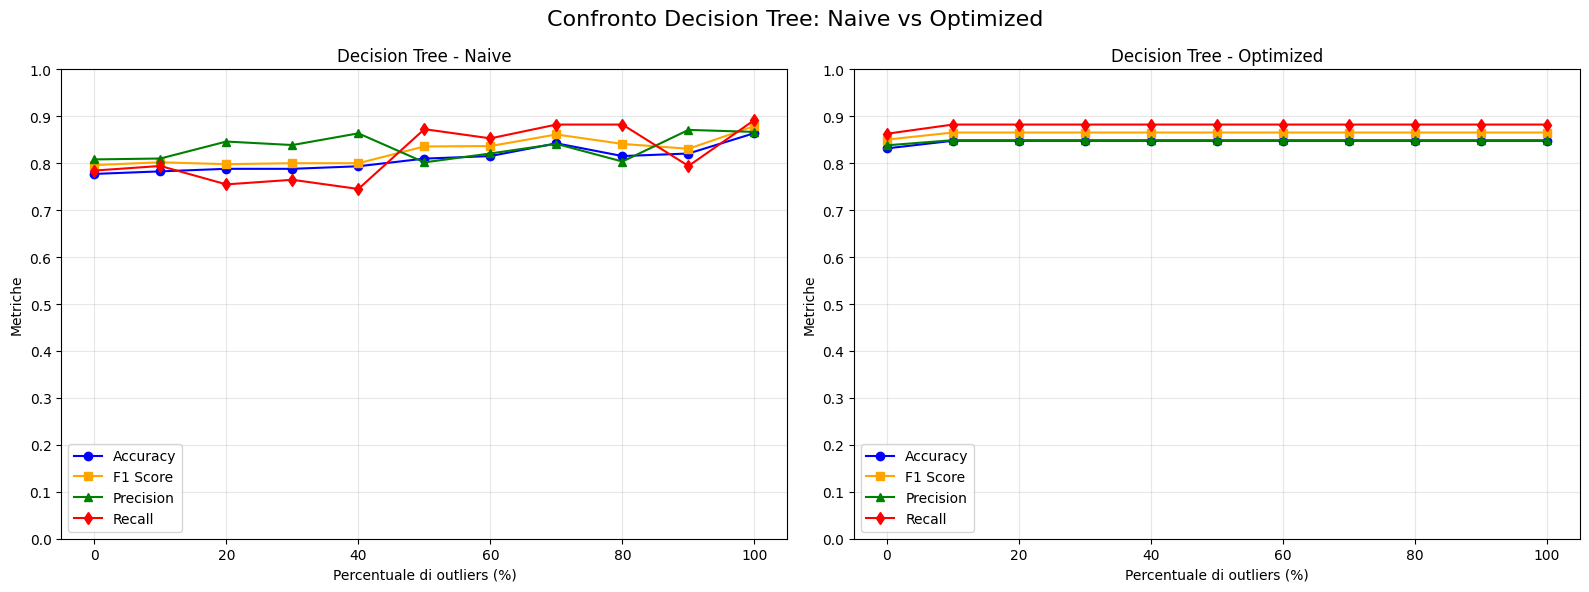

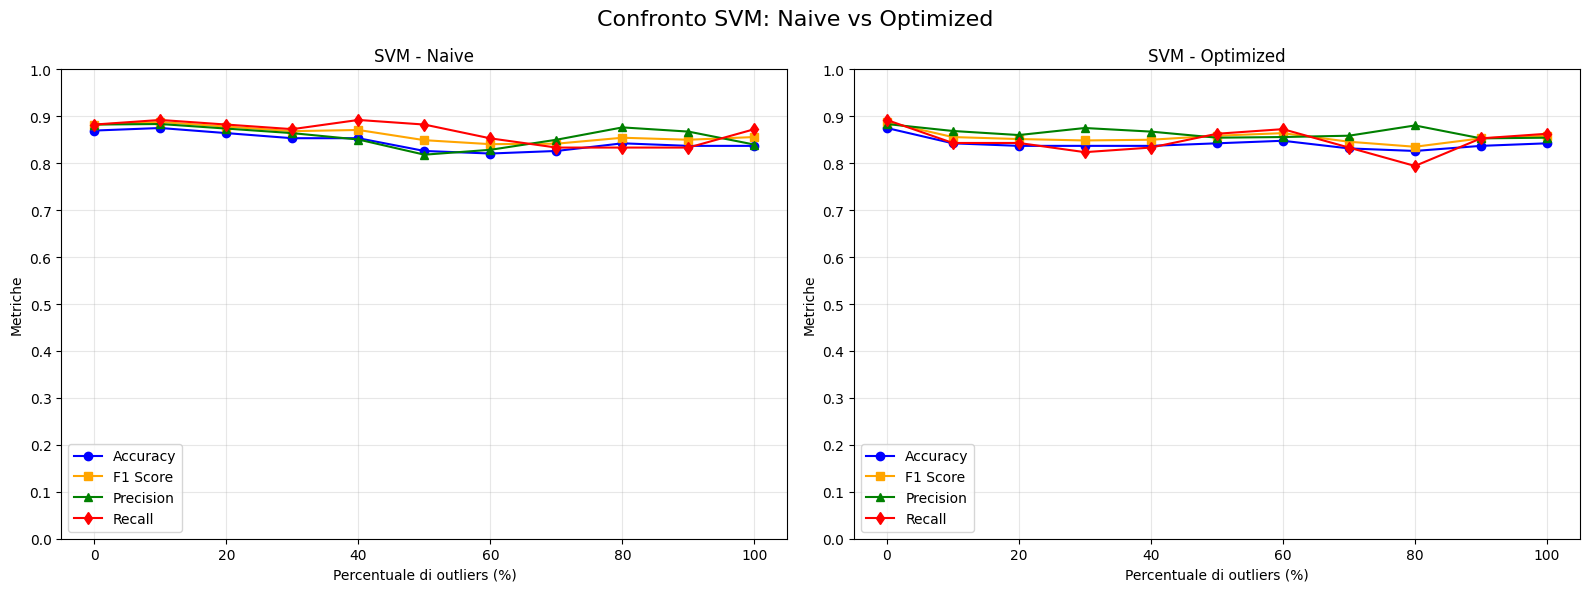

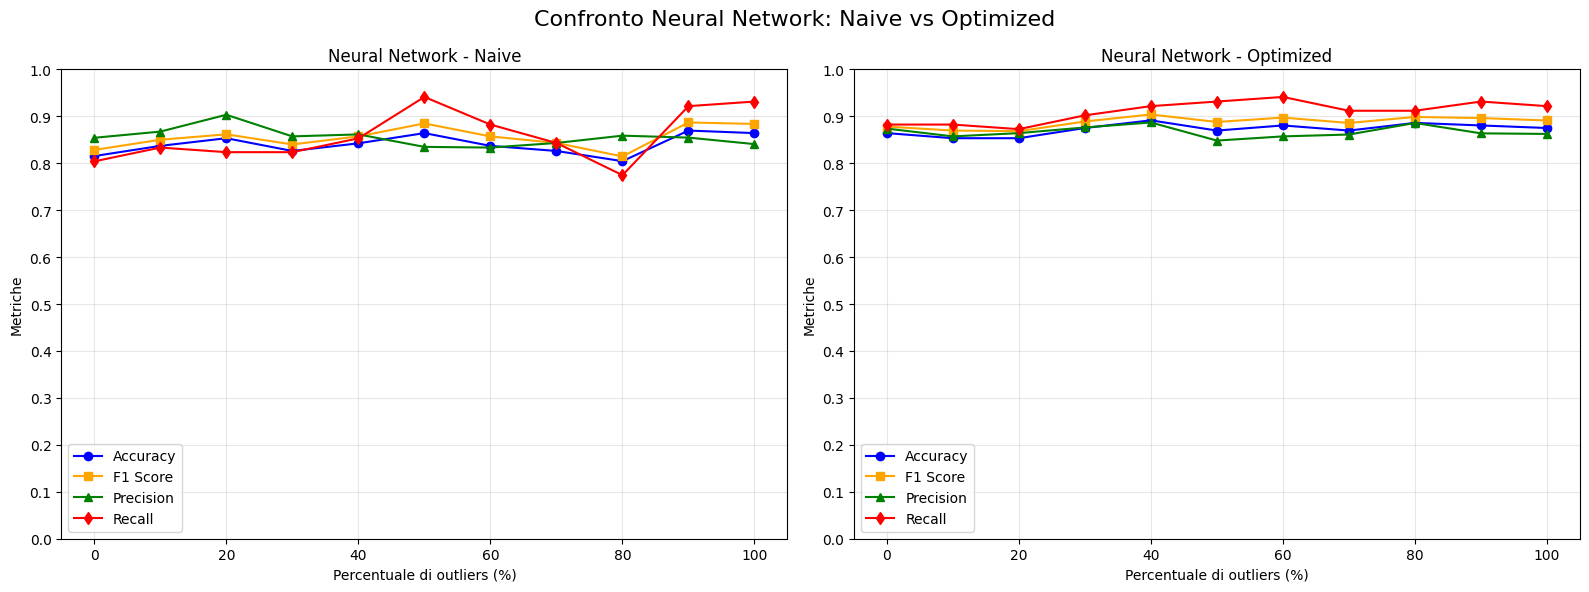

In [613]:
# 3. Confronto Naive vs Optimized per un modello
def plot_naive_vs_optimized(model_name):
    """Confronta approccio Naive vs Optimized per un modello"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, approach in enumerate(['Naive', 'Optimized']):
        # Prepara dati
        contam_df = pd.DataFrame([
            {"step": h['step'], "contamination_rate": h['actual_rate']}
            for h in contamination_history
        ])
        
        if 0 not in contam_df["step"].values:
            contam_df = pd.concat([
                pd.DataFrame([{"step": 0, "contamination_rate": 0.0}]),
                contam_df
            ], ignore_index=True)
        
        metrics_df = pd.DataFrame(all_metrics_outliers)
        merged_df = pd.merge(metrics_df, contam_df, on="step", how="left")
        merged_df = merged_df.sort_values("contamination_rate")
        
        filtered_df = merged_df[
            (merged_df["approach"] == approach) & 
            (merged_df["model"] == model_name)
        ]
        
        # Plot su subplot
        axes[i].plot(filtered_df["contamination_rate"]*100, filtered_df["accuracy"], 
                    marker='o', color='blue', label="Accuracy")
        axes[i].plot(filtered_df["contamination_rate"]*100, filtered_df["f1_score"], 
                    marker='s', color='orange', label="F1 Score")
        axes[i].plot(filtered_df["contamination_rate"]*100, filtered_df["precision"], 
                    marker='^', color='green', label="Precision")
        axes[i].plot(filtered_df["contamination_rate"]*100, filtered_df["recall"], 
                    marker='d', color='red', label="Recall")
        
        axes[i].set_xlabel("Percentuale di outliers (%)")
        axes[i].set_ylabel("Metriche")
        axes[i].set_title(f"{model_name} - {approach}")
        axes[i].set_yticks(np.arange(0, 1.1, 0.1))
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    
    plt.suptitle(f"Confronto {model_name}: Naive vs Optimized", fontsize=16)
    plt.xticks(np.arange(0,110,20))
    plt.tight_layout()
    plt.show()


plot_naive_vs_optimized('Decision Tree')
plot_naive_vs_optimized('SVM')
plot_naive_vs_optimized('Neural Network')

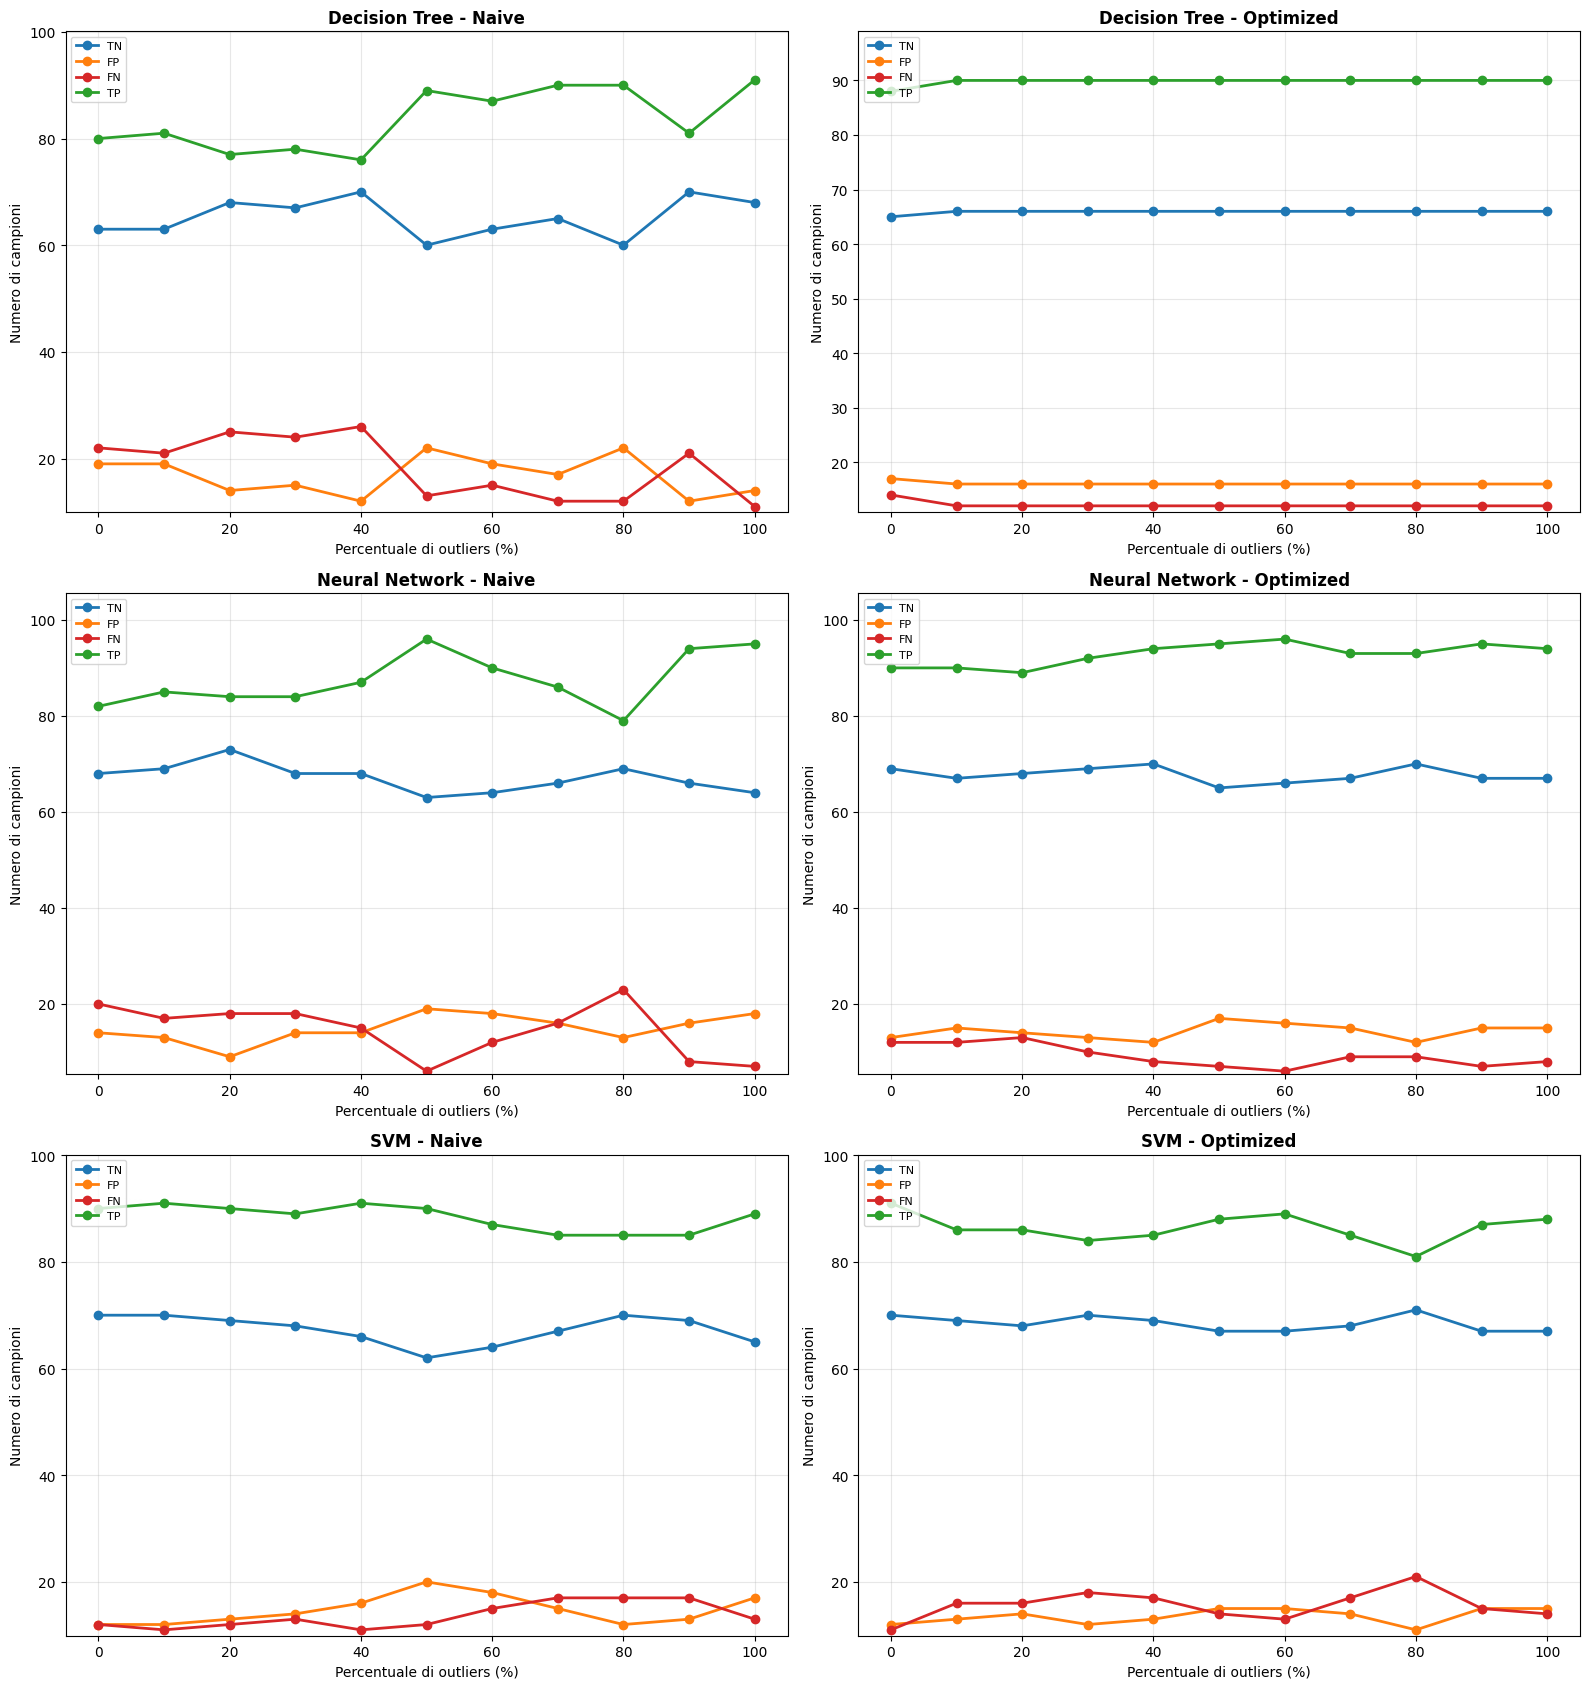

In [614]:
def plot_confusion_matrix_grid(confusion_matrix_values, contamination_history=None):
    """
    Crea una griglia di grafici 2 colonne x N righe (Naive | Optimized per modello)
    
    Parameters:
    -----------
    confusion_matrix_values : dict
        Dizionario con i valori delle confusion matrix
    contamination_history : list, optional
        Storia della contaminazione con step e actual_rate (default: usa step numerici)
    """
    
    # Estrai tutti i modelli unici (DT, SVM, NN)
    models = sorted(set(key.split(' - ')[0] for key in confusion_matrix_values.keys()))
    
    # Setup subplot: 2 colonne (Naive, Optimized), righe = numero modelli
    fig, axes = plt.subplots(len(models), 2, figsize=(16, 17))
    
    # Se c'è solo un modello, axes diventa 1D → forzo 2D
    if len(models) == 1:
        axes = [axes]
    
    colors = {
        'TN': '#1f77b4',  # blu
        'FP': '#ff7f0e',  # arancione  
        'FN': '#d62728',  # rosso
        'TP': '#2ca02c'   # verde
    }
    
    for model_idx, model in enumerate(models):
        for col_idx, approach in enumerate(["Naive", "Optimized"]):
            ax = axes[model_idx][col_idx]
            
            # Trova la chiave corretta (es: "Decision Tree - Naive")
            model_key = f"{model} - {approach}"
            if model_key not in confusion_matrix_values:
                continue
            
            # Estrai gli step
            steps = sorted(confusion_matrix_values[model_key].keys())
            
            if contamination_history is None:
                x_values = steps
                x_label = "Step"
            else:
                # mapping step -> contamination_rate
                contam_dict = {h['step']: h['actual_rate'] for h in contamination_history}
                if 0 not in contam_dict:
                    contam_dict[0] = 0.0
                x_values = [contam_dict.get(step, 0) * 100 for step in steps]
                x_label = "Percentuale di outliers (%)"
            
            # Estrai valori TN, FP, FN, TP
            metrics_data = {
                'TN': [confusion_matrix_values[model_key][step]['TN'] for step in steps],
                'FP': [confusion_matrix_values[model_key][step]['FP'] for step in steps],
                'FN': [confusion_matrix_values[model_key][step]['FN'] for step in steps],
                'TP': [confusion_matrix_values[model_key][step]['TP'] for step in steps]
            }
            
            # Plot linee
            for metric in ['TN', 'FP', 'FN', 'TP']:
                ax.plot(x_values, metrics_data[metric], 
                        color=colors[metric], 
                        marker='o',
                        linestyle='-',
                        label=metric,
                        linewidth=2,
                        markersize=6)
            
            # Personalizza subplot
            ax.set_title(f"{model} - {approach}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel("Numero di campioni", fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='upper left')
            
            # Limiti Y dinamici
            all_values = [v for metric in metrics_data.values() for v in metric]
            ax.set_ylim(min(all_values) * 0.9, max(all_values) * 1.1)
    
    plt.tight_layout()
    plt.show()

# Usa la funzione corretta
plot_confusion_matrix_grid(confusion_matrix_values, contamination_history)

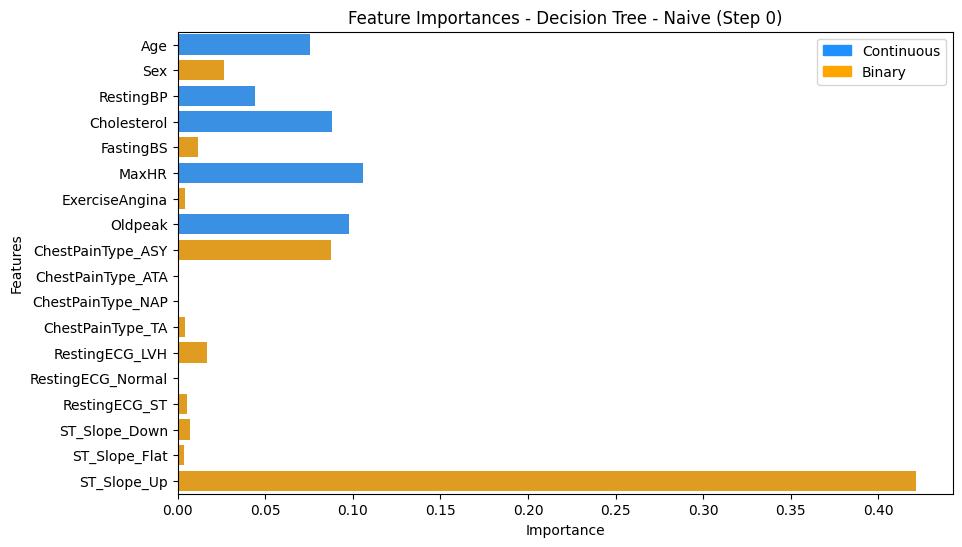

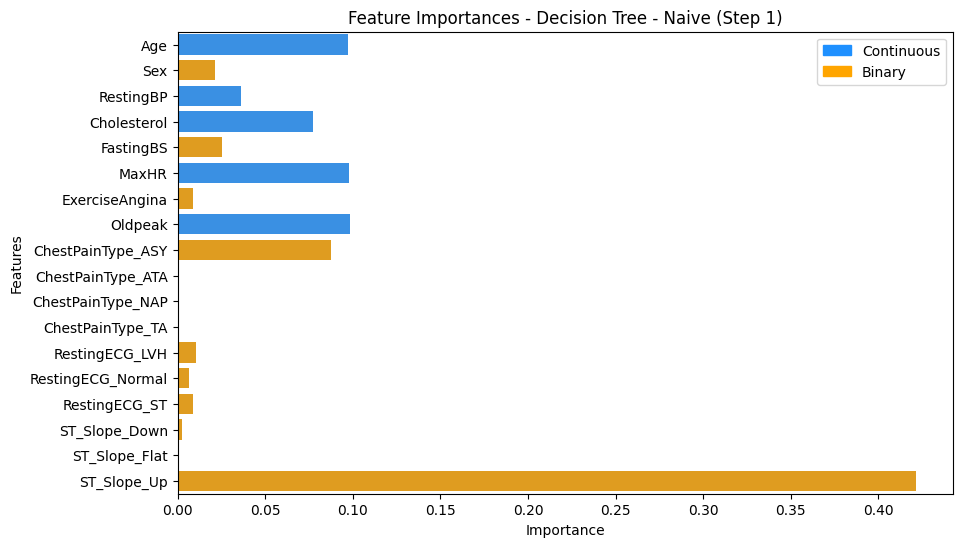

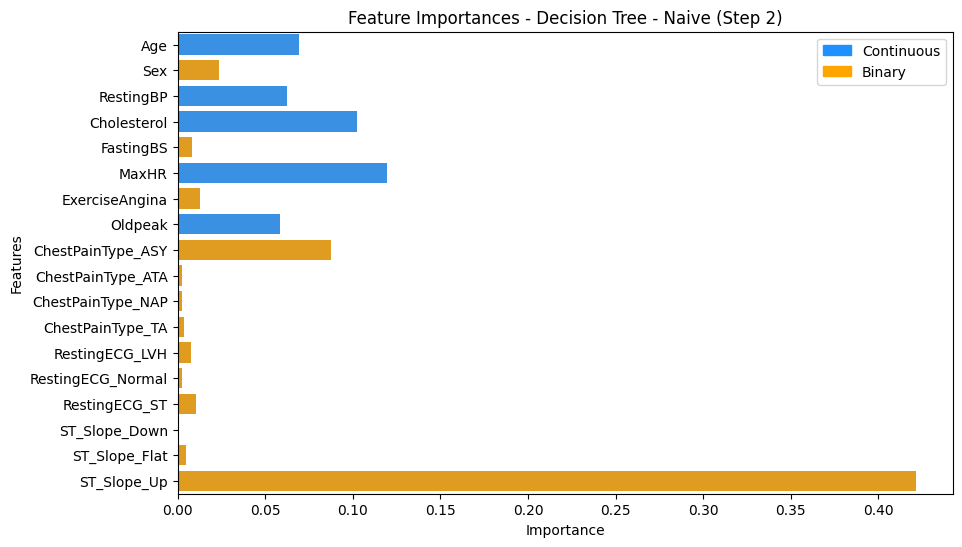

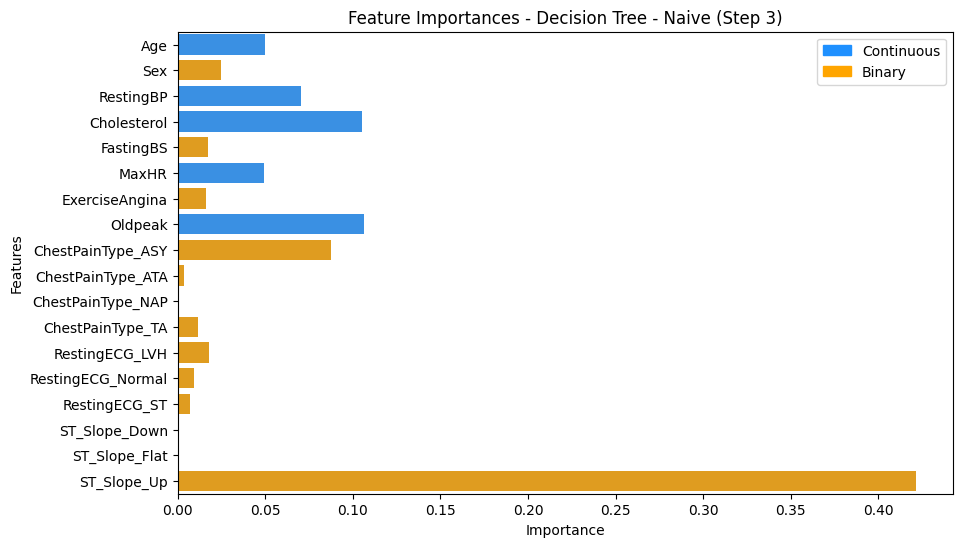

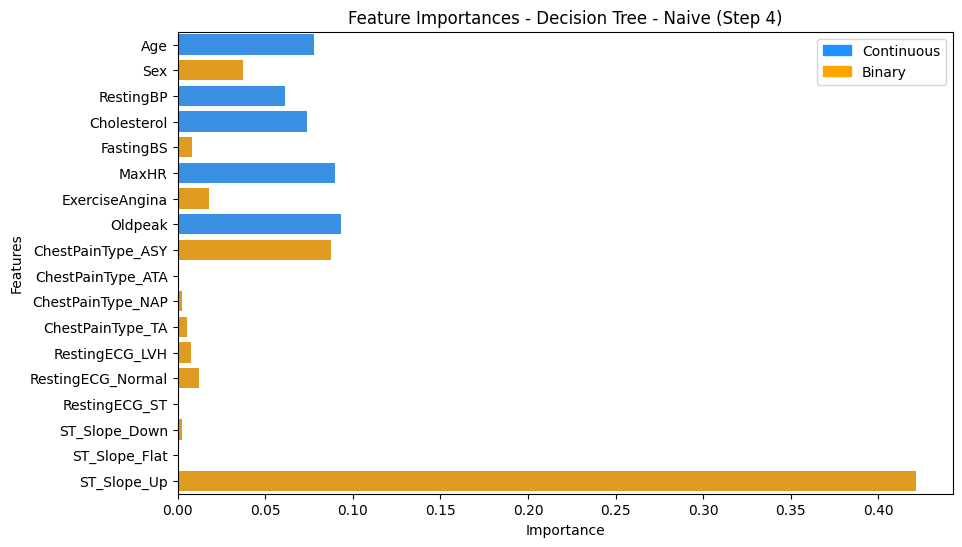

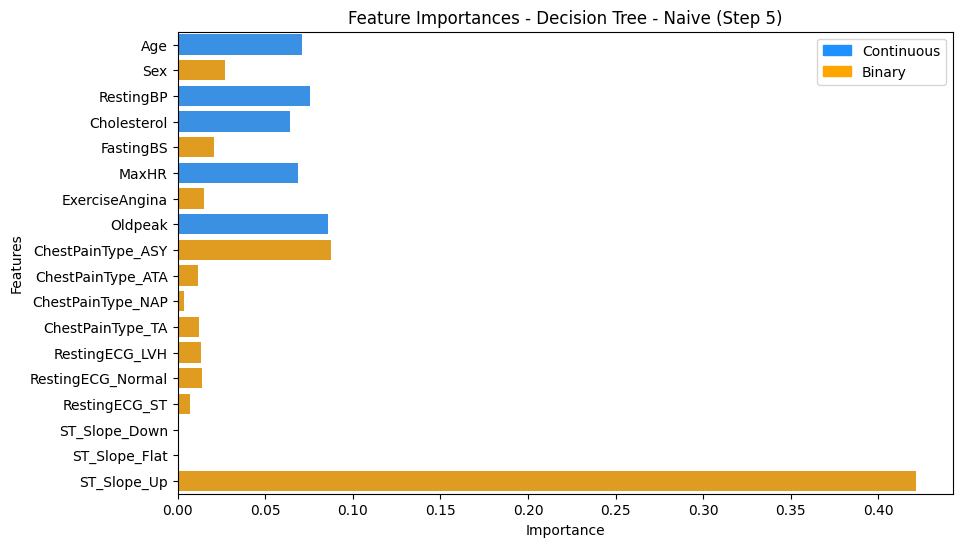

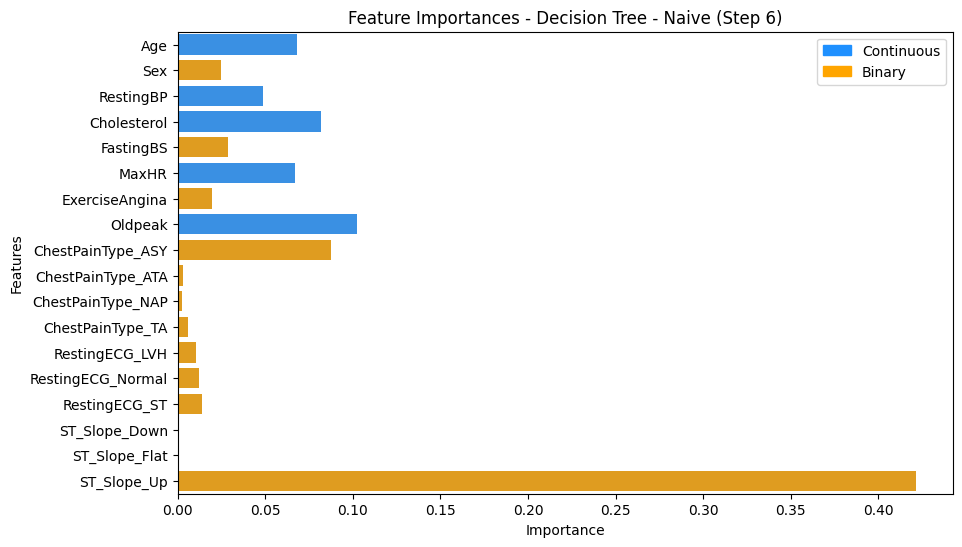

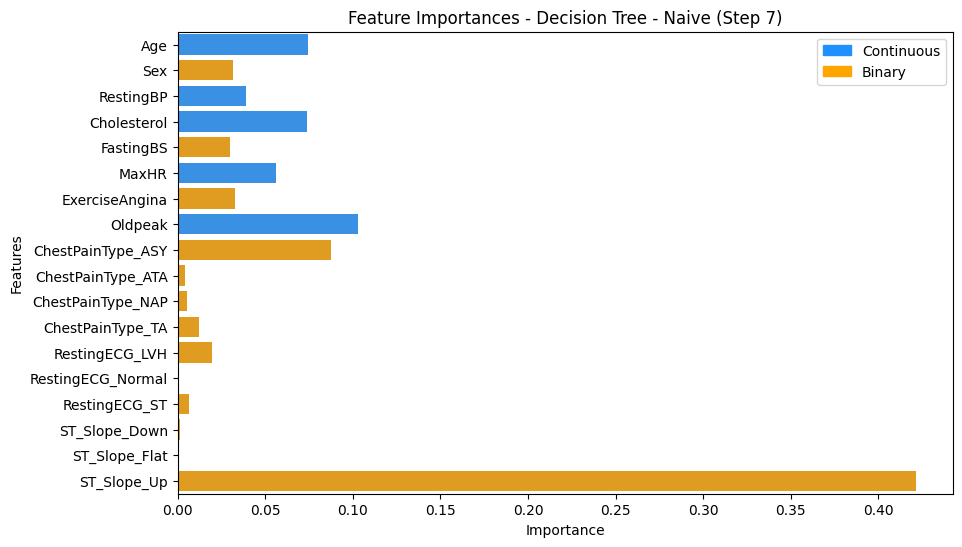

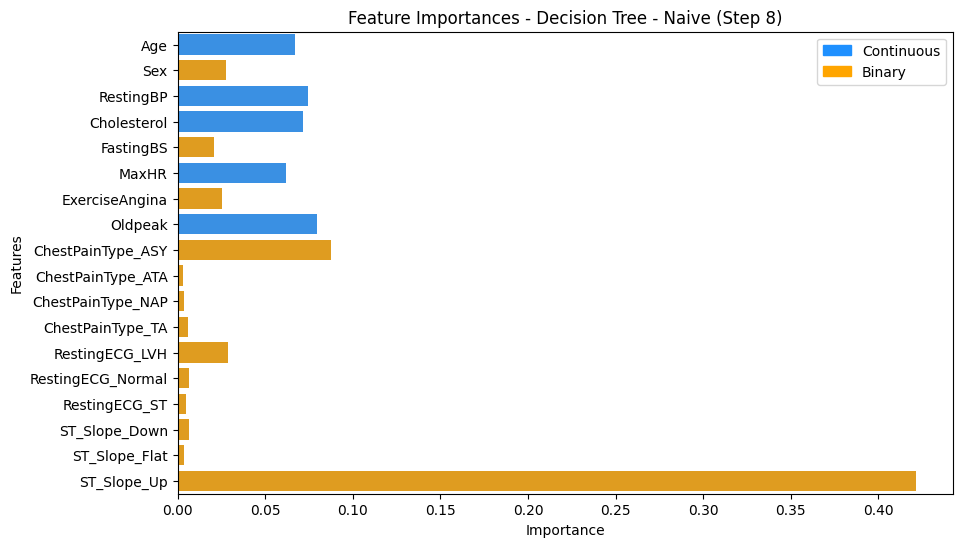

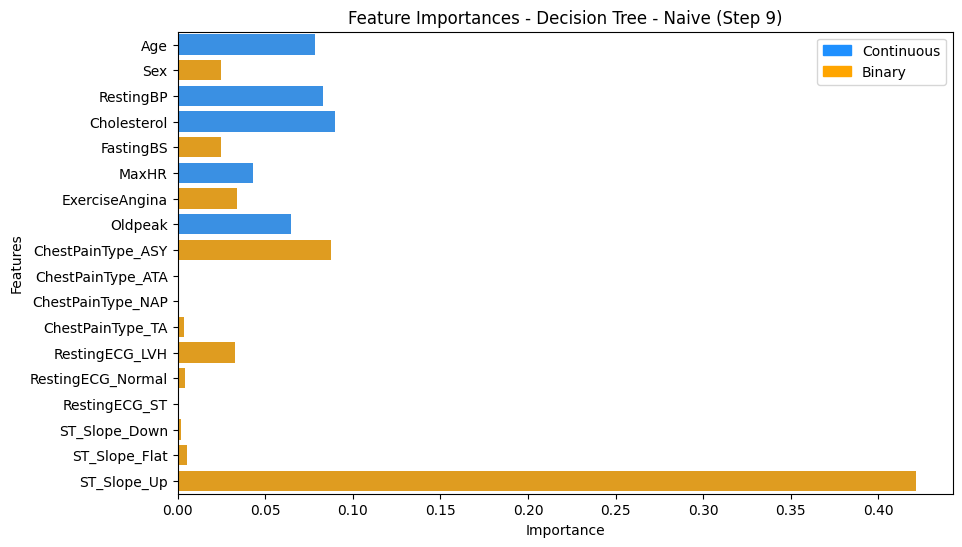

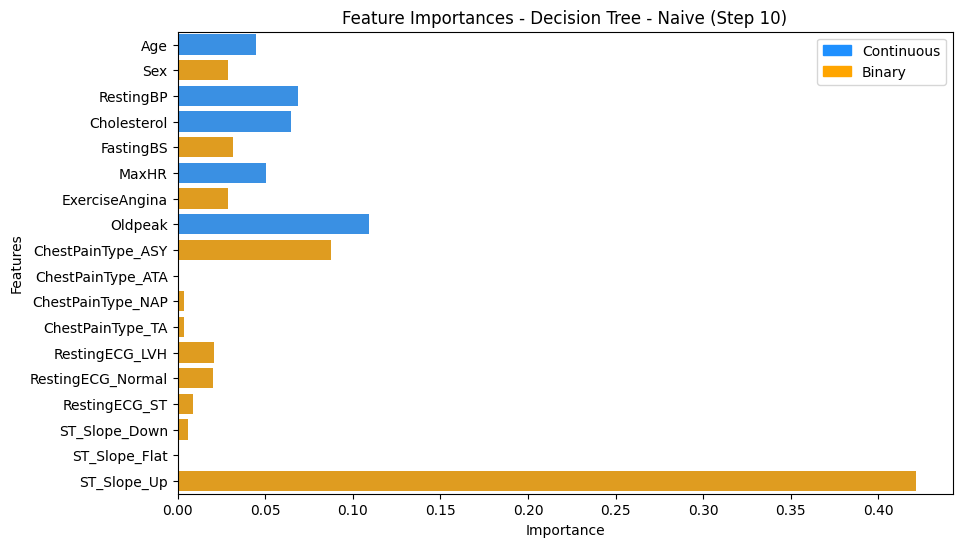

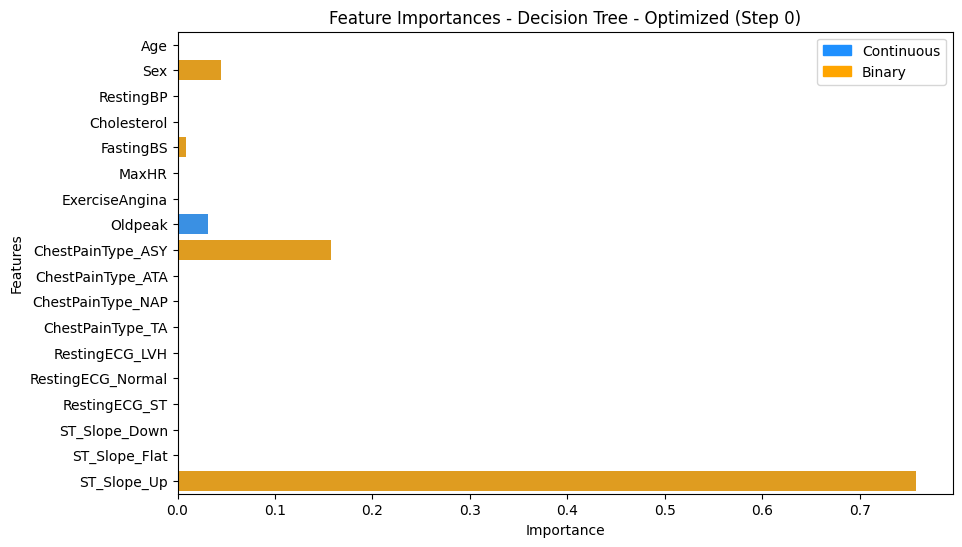

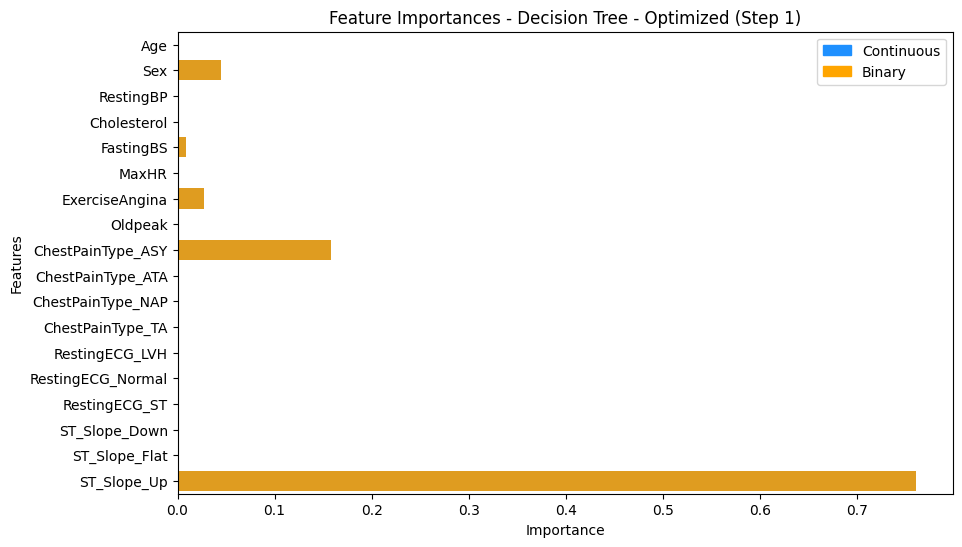

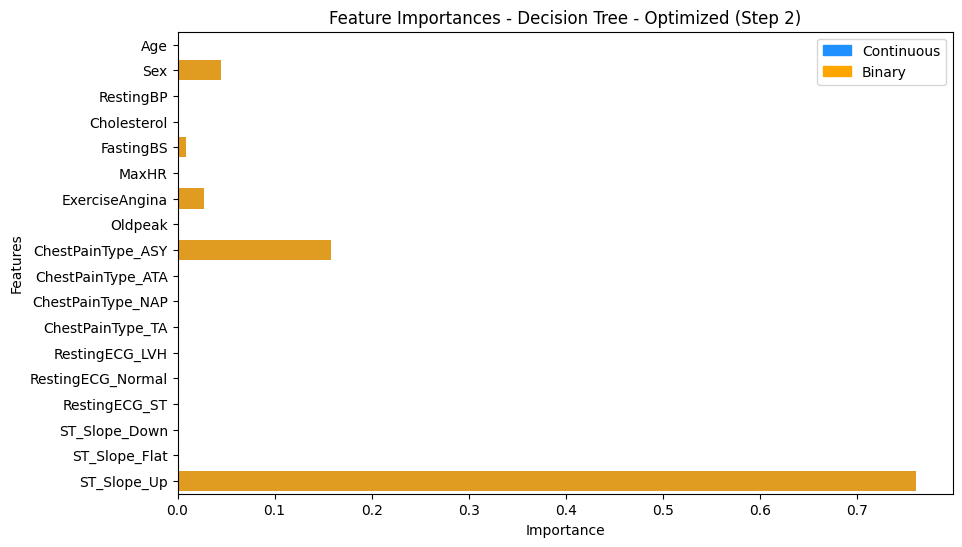

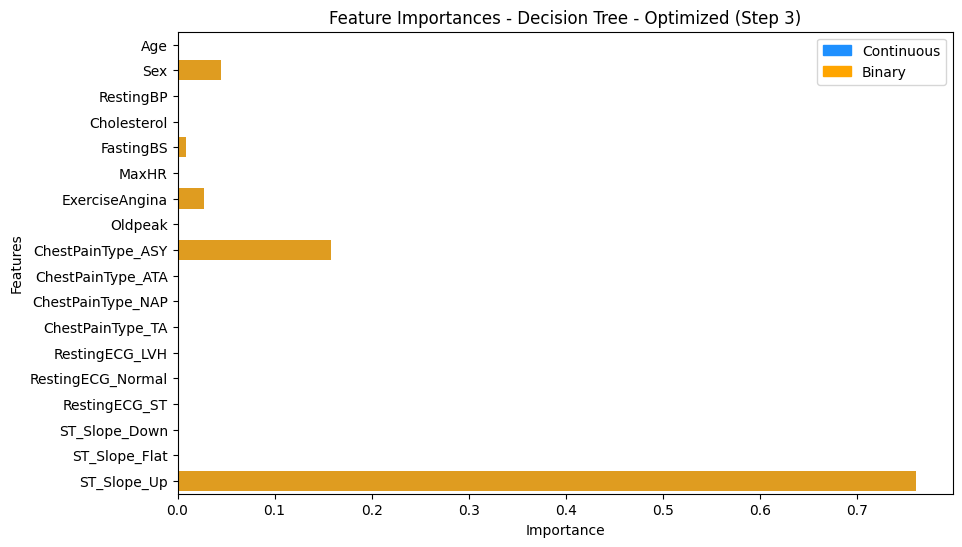

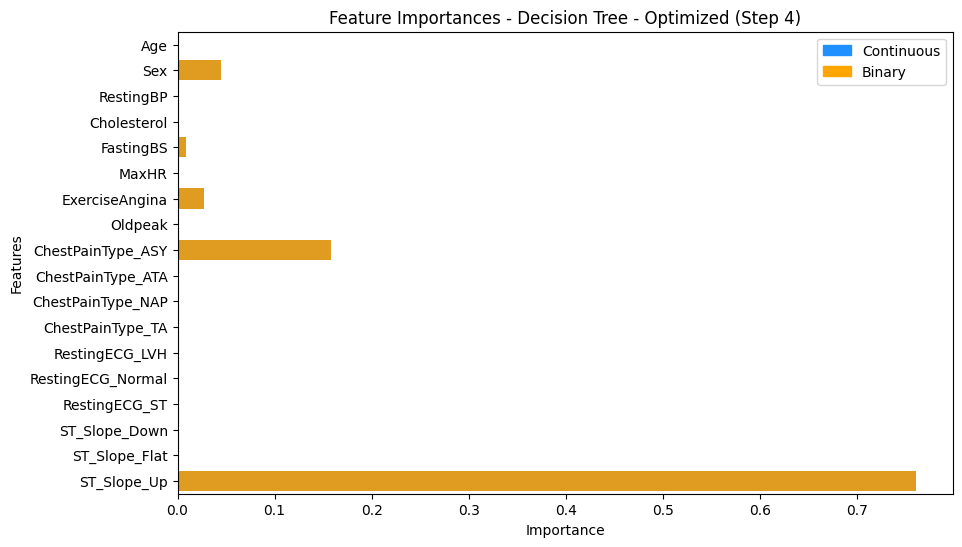

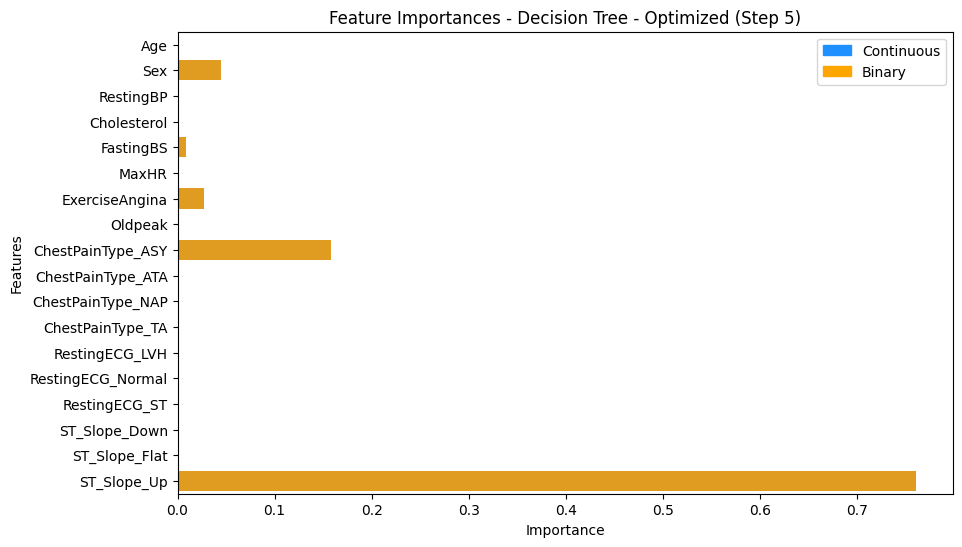

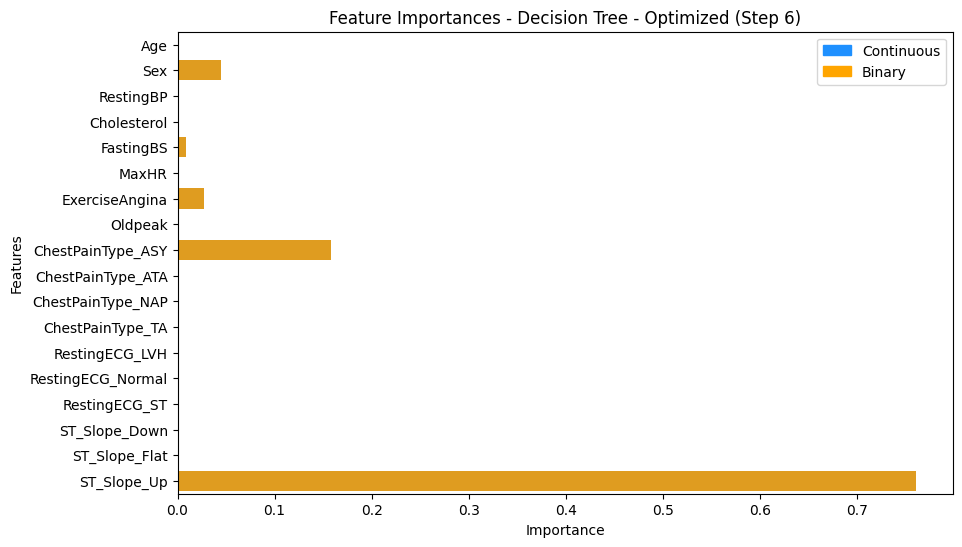

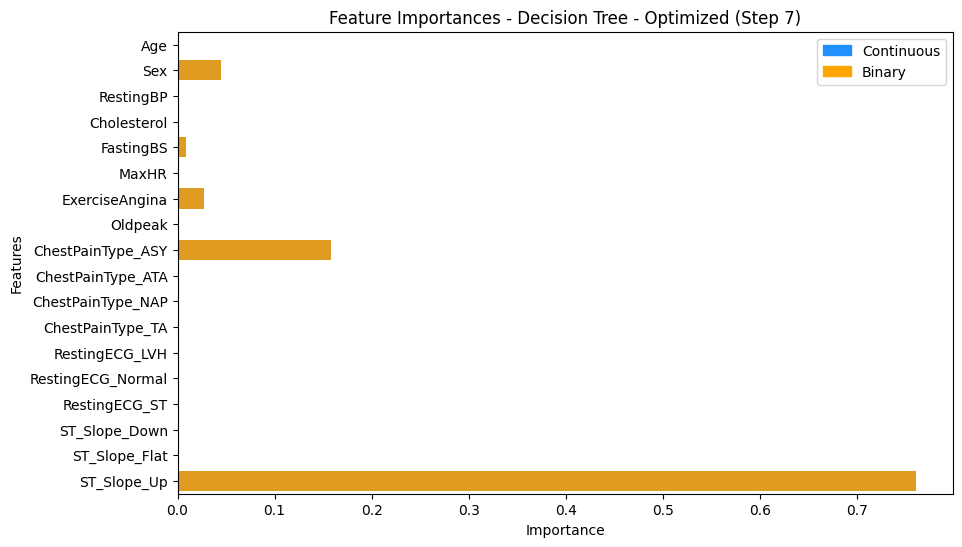

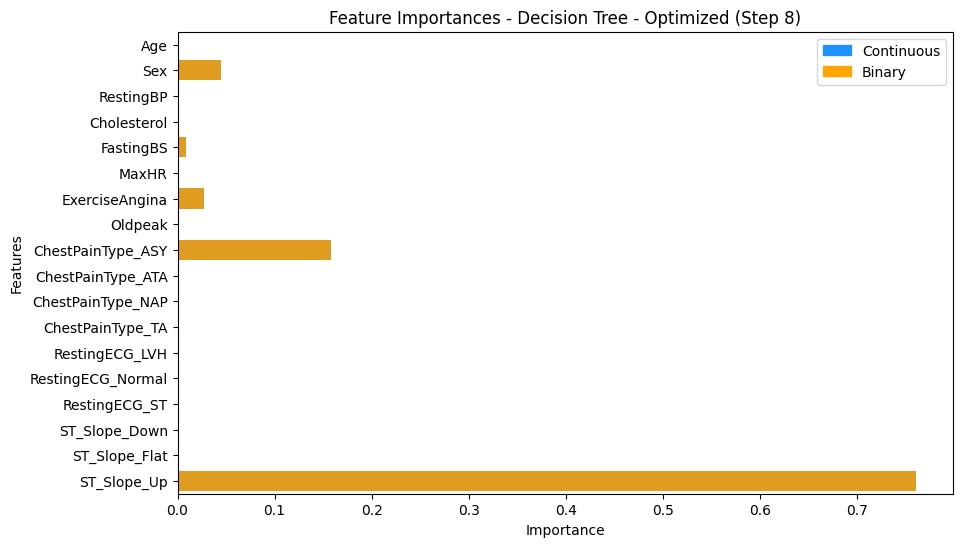

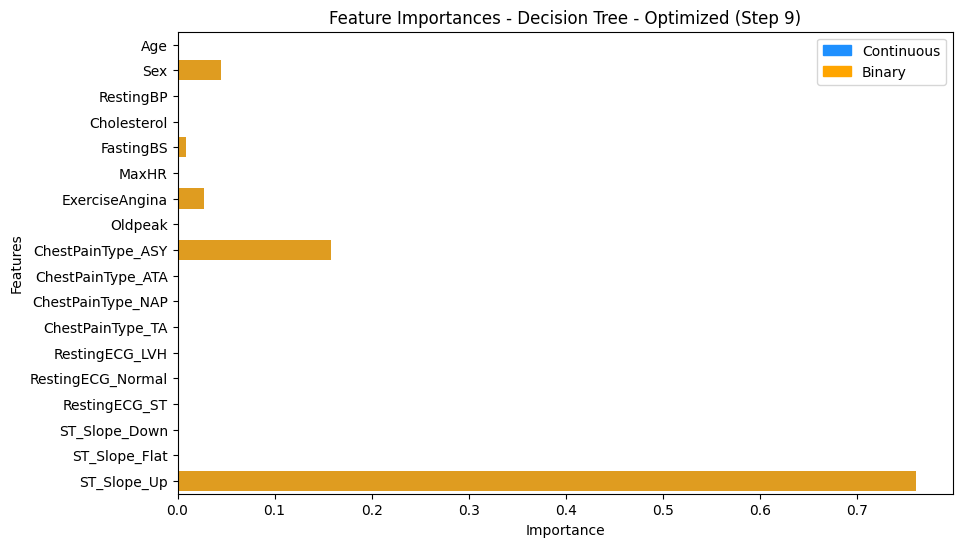

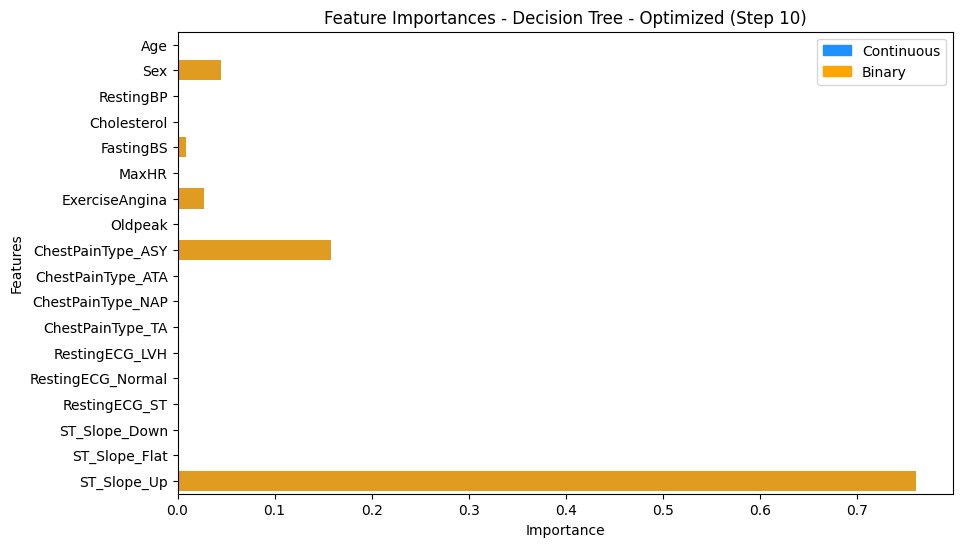

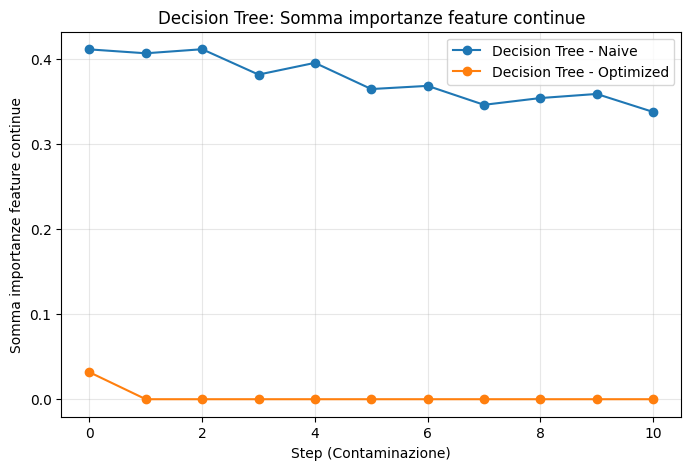

'\nplt.figure(figsize=(8, 5))\nfor key in feature_importances:\n    if "SVM" in key:\n        steps = []\n        sum_importances = []\n        for step, importances in feature_importances[key].items():\n            sum_continuous = sum(\n                imp for imp, feat in zip(importances, X_original.columns)\n                if feat in continuous_features\n            )\n            steps.append(step)\n            sum_importances.append(sum_continuous)\n        plt.plot(steps, sum_importances, marker=\'o\', label=key)\nplt.xlabel("Step (Contaminazione)")\nplt.ylabel("Somma importanze feature continue")\nplt.title("SVM: Somma importanze feature continue")\nplt.legend()\nplt.grid(True, alpha=0.3)\nplt.show()\n'

In [615]:
import matplotlib.patches as mpatches

for key in feature_importances:
    for step, importances in feature_importances[key].items():
        plt.figure(figsize=(10, 6))
        feature_names = list(X_original.columns)
        colors = ['dodgerblue' if feat in continuous_features else 'orange' for feat in feature_names]
        sns.barplot(x=importances, y=feature_names, palette=colors)
        plt.title(f"Feature Importances - {key} (Step {step})")
        plt.xlabel("Importance")
        plt.ylabel("Features")
        blue_patch = mpatches.Patch(color='dodgerblue', label='Continuous')
        orange_patch = mpatches.Patch(color='orange', label='Binary')
        plt.legend(handles=[blue_patch, orange_patch])
        plt.show()

# Calcola la somma delle importanze delle feature continue per ogni step e approccio
# --- Decision Tree ---
plt.figure(figsize=(8, 5))
for key in feature_importances:
    if "Decision Tree" in key:
        steps = []
        sum_importances = []
        for step, importances in feature_importances[key].items():
            sum_continuous = sum(
                imp for imp, feat in zip(importances, X_original.columns)
                if feat in continuous_features
            )
            steps.append(step)
            sum_importances.append(sum_continuous)
        plt.plot(steps, sum_importances, marker='o', label=key)
plt.xlabel("Step (Contaminazione)")
plt.ylabel("Somma importanze feature continue")
plt.title("Decision Tree: Somma importanze feature continue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- SVM ---
'''
plt.figure(figsize=(8, 5))
for key in feature_importances:
    if "SVM" in key:
        steps = []
        sum_importances = []
        for step, importances in feature_importances[key].items():
            sum_continuous = sum(
                imp for imp, feat in zip(importances, X_original.columns)
                if feat in continuous_features
            )
            steps.append(step)
            sum_importances.append(sum_continuous)
        plt.plot(steps, sum_importances, marker='o', label=key)
plt.xlabel("Step (Contaminazione)")
plt.ylabel("Somma importanze feature continue")
plt.title("SVM: Somma importanze feature continue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
'''

=== ANALISI DELL'IMPATTO DELLE FEATURE ===



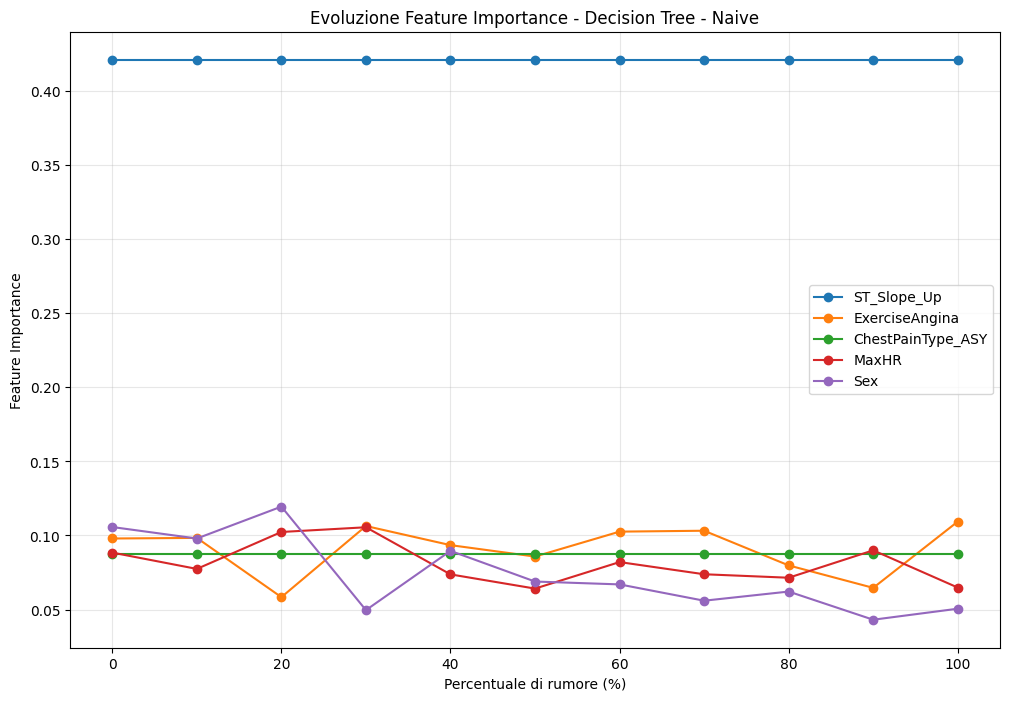


Decision Tree - Naive:
Media importanza feature continue: 0.0520
Media importanza feature binarie: 0.0569


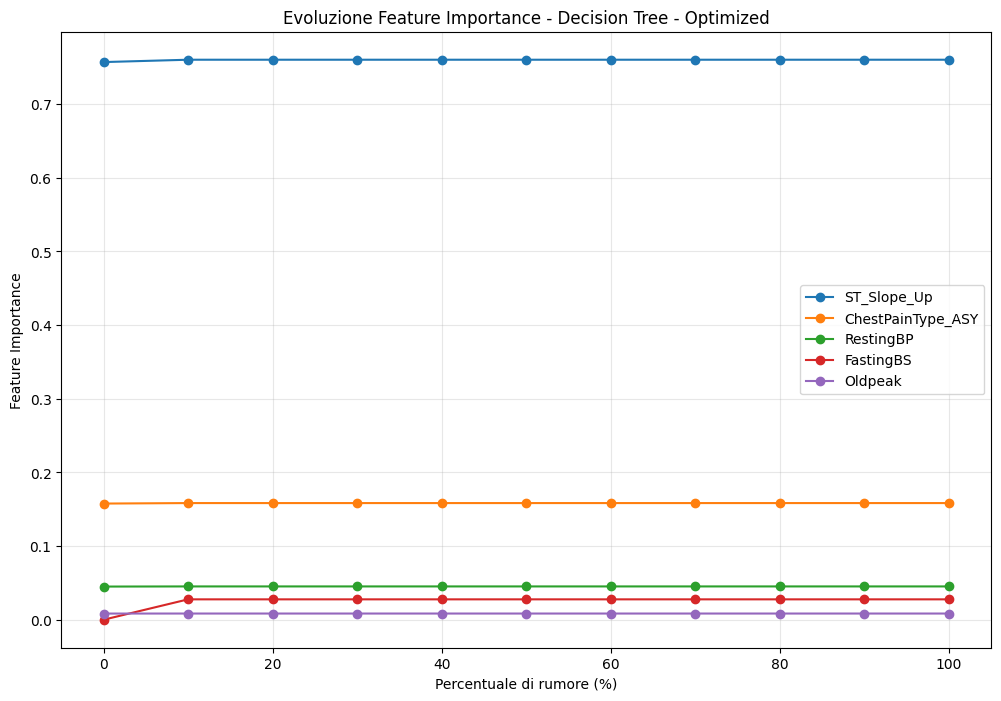


Decision Tree - Optimized:
Media importanza feature continue: 0.0107
Media importanza feature binarie: 0.0728


In [616]:
# %%
# ANALISI AGGIUNTIVE PER IL PROGETTO MISSING VALUES

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

'''
# %%
# 4. ANALISI ROC E CALIBRAZIONE
def roc_calibration_analysis(all_metrics_duplicates, duplicated_dfs, X_test_clean, y_test_clean):
    """
    Analisi delle curve ROC e della calibrazione dei modelli
    """
    print("=== ANALISI ROC E CALIBRAZIONE ===\n")
    
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.svm import SVC
    from sklearn.neural_network import MLPClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.impute import SimpleImputer
    from sklearn.calibration import CalibratedClassifierCV
    
    # Testa su alcuni step rappresentativi
    test_steps = [0.1, 0.3, 0.5]
    models_config = {
        'Decision Tree': DecisionTreeClassifier(),
        'SVM': SVC(probability=True),
        'Neural Network': MLPClassifier(max_iter=1000)
    }
    
    fig, axes = plt.subplots(len(test_steps), 3, figsize=(18, 6*len(test_steps)))
    if len(test_steps) == 1:
        axes = axes.reshape(1, -1)
    
    roc_results = []
    
    for step_idx, perc in enumerate(test_steps):
        if perc not in duplicated_dfs:
            continue

        df_degraded = duplicated_dfs[perc]
        X_contaminated = df_degraded.drop('HeartDisease', axis=1)
        y_contaminated = df_degraded['HeartDisease']
        
        X_train, _, y_train, _ = train_test_split(
            X_contaminated, y_contaminated, test_size=0.2, random_state=42
        )
        
        imputer = SimpleImputer(strategy='mean')
        X_train_imp = imputer.fit_transform(X_train)
        X_test_imp = imputer.transform(X_test_clean)
        
        for model_idx, (model_name, model) in enumerate(models_config.items()):
            model.fit(X_train_imp, y_train)
            
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test_imp)[:, 1]
            else:
                y_proba = model.decision_function(X_test_imp)
            
            # ROC Curve
            fpr, tpr, _ = roc_curve(y_test_clean, y_proba)
            auc_score = roc_auc_score(y_test_clean, y_proba)
            
            axes[step_idx, model_idx].plot(fpr, tpr, label=f'ROC (AUC={auc_score:.3f})')
            axes[step_idx, model_idx].plot([0, 1], [0, 1], 'k--', alpha=0.5)
            axes[step_idx, model_idx].set_xlabel('False Positive Rate')
            axes[step_idx, model_idx].set_ylabel('True Positive Rate')
            axes[step_idx, model_idx].set_title(f'{model_name} - {int(perc*100)}% Missing')
            axes[step_idx, model_idx].legend()
            axes[step_idx, model_idx].grid(True, alpha=0.3)
            
            roc_results.append({
                'model': model_name,
                'missing_perc': perc,
                'auc_score': auc_score
            })
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(roc_results)

'''

# %%
# 5. ANALISI DELL'IMPATTO SPECIFICO DELLE FEATURE
def feature_impact_analysis(feature_importances, continuous_features, binary_features):
    """
    Analizza come l'importanza delle feature cambia con l'aumento dei missing values
    """

    # Rimuovi la target dalle liste se presente
    continuous_features = [f for f in continuous_features if f != 'HeartDisease']
    binary_features = [f for f in binary_features if f != 'HeartDisease']

    print("=== ANALISI DELL'IMPATTO DELLE FEATURE ===\n")
    
    if not feature_importances:
        print("Nessuna feature importance disponibile")
        return
    
    # Solo per Decision Tree che ha feature_importances
    for model_approach, step_importances in feature_importances.items():
        if 'Decision Tree' not in model_approach:
            continue
            
        # Crea DataFrame delle importanze per step
        importance_data = []
        for step, importances in step_importances.items():
            # Verifica che importances sia un array/lista valida
            if importances is not None and len(importances) > 0:
                for feat_idx, importance in enumerate(importances):
                    importance_data.append({
                        'step': step,
                        'feature_idx': feat_idx,
                        'importance': importance
                    })
        
        if not importance_data:
            continue
            
        importance_df = pd.DataFrame(importance_data)
        
        # Visualizza l'evoluzione delle top 5 feature più importanti
        plt.figure(figsize=(12, 8))
        
        # Trova le top feature basate sull'importanza media
        avg_importance = importance_df.groupby('feature_idx')['importance'].mean().sort_values(ascending=False)
        top_features = avg_importance.head(5).index
        
        for feat_idx in top_features:
            feat_data = importance_df[importance_df['feature_idx'] == feat_idx].sort_values('step')
            # Ottieni il nome della feature corrispondente all'indice
            if feat_idx < len(continuous_features):
                feat_name = continuous_features[feat_idx]
            elif feat_idx < len(continuous_features) + len(binary_features):
                feat_name = binary_features[feat_idx - len(continuous_features)]
            else:
                feat_name = f"Feature {feat_idx}"
            plt.plot(feat_data['step']*10, feat_data['importance'], 
                    marker='o', label=feat_name)

        plt.xlabel('Percentuale di rumore (%)')
        plt.ylabel('Feature Importance')
        plt.title(f'Evoluzione Feature Importance - {model_approach}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Analisi separata per feature continue vs binarie (se hai i nomi delle feature)
        print(f"\n{model_approach}:")
        
        # Verifica che gli indici esistano prima di accedervi
        continuous_indices = [i for i in range(len(continuous_features)) if i in avg_importance.index]
        binary_start = len(continuous_features)
        binary_end = len(continuous_features) + len(binary_features)
        binary_indices = [i for i in range(binary_start, binary_end) if i in avg_importance.index]
        
        if continuous_indices:
            print(f"Media importanza feature continue: {avg_importance[continuous_indices].mean():.4f}")
        else:
            print("Nessuna feature continua trovata negli indici")
            
        if binary_indices:
            print(f"Media importanza feature binarie: {avg_importance[binary_indices].mean():.4f}")
        else:
            print("Nessuna feature binaria trovata negli indici")


# Esegui l'analisi comprehensive:
comprehensive_results = feature_impact_analysis(
    feature_importances, continuous_features, binary_features
)

   MI_numerical  MI_binary  perc_outliers
0      0.072903   0.105932            0.1
1      0.057229   0.105932            0.2
2      0.051331   0.105932            0.3
3      0.039533   0.105932            0.4
4      0.038447   0.105932            0.5
5      0.029260   0.105932            0.6
6      0.020863   0.105932            0.7
7      0.015872   0.105932            0.8
8      0.008864   0.105932            0.9
9      0.006097   0.105932            1.0


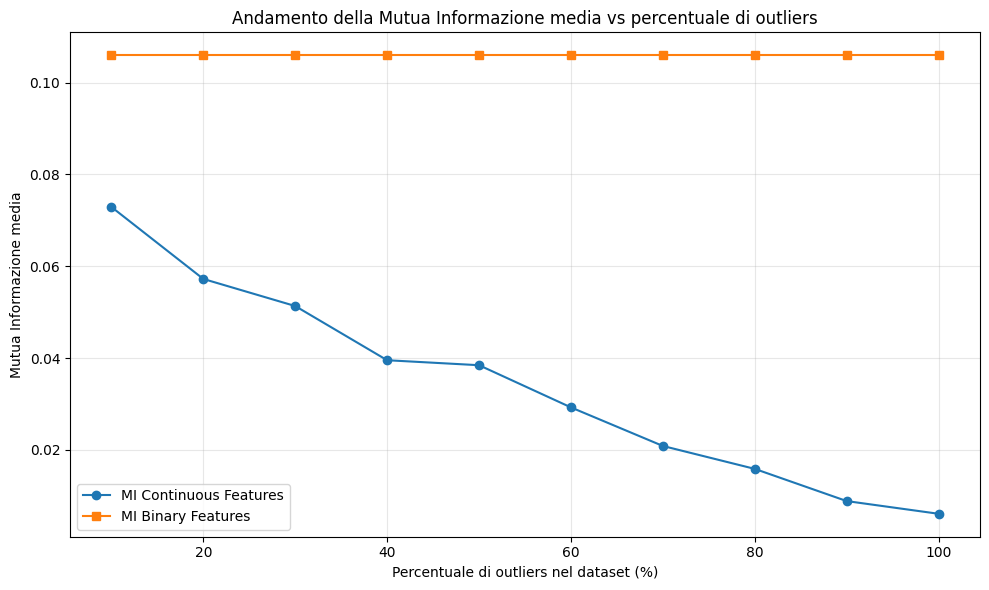

In [617]:
df_results = pd.DataFrame(mutua_informazione_feature)
print(df_results)

plt.figure(figsize=(10, 6))
plt.plot(df_results["perc_outliers"]*100, df_results["MI_numerical"], marker='o', label="MI Continuous Features")
plt.plot(df_results["perc_outliers"]*100, df_results["MI_binary"], marker='s', label="MI Binary Features")
plt.xlabel("Percentuale di outliers nel dataset (%)")
plt.ylabel("Mutua Informazione media")
plt.title("Andamento della Mutua Informazione media vs percentuale di outliers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()